In [7]:
import pandas as pd

train = pd.read_csv('train_dataset.csv')
total = len(train)
print(f"TRAIN_DATASET.CSV  — строк: {total}, колонок: {len(train.columns)}")
print(f"{'Колонка':<35} {'Заполнено':>10} {'Пустых':>8}")
print("-" * 55)
for col in train.columns:
    filled = train[col].notna().sum()
    empty = train[col].isna().sum()
    print(f"{col:<35} {filled:>10} {empty:>8}")

TRAIN_DATASET.CSV  — строк: 32434, колонок: 21
Колонка                              Заполнено   Пустых
-------------------------------------------------------
METEOFORECASTHOUR_OPENM_Datetime         32434        0
month                                    32434        0
hour_of_day                              32434        0
Выработка. Результирующий расчет         32434        0
wind_speed_10m                           32434        0
wind_speed_80m                           32434        0
wind_speed_120m                          32434        0
wind_speed_180m                          25598     6836
wind_direction_10m                       32434        0
wind_direction_80m                       32434        0
wind_direction_120m                      32434        0
wind_direction_180m                      25598     6836
wind_gusts_10m                           32434        0
temperature_80m                          32434        0
temperature_120m                         32434        0
p

In [8]:
import pandas as pd

valid = pd.read_csv('valid_features.csv')
total = len(valid)
print(f"VALID_FEATURES.CSV — строк: {total}, колонок: {len(valid.columns)}")
print(f"{'Колонка':<35} {'Заполнено':>10} {'Пустых':>8}")
print("-" * 55)
for col in valid.columns:
    filled = valid[col].notna().sum()
    empty = valid[col].isna().sum()
    print(f"{col:<35} {filled:>10} {empty:>8}")

VALID_FEATURES.CSV — строк: 2126, колонок: 20
Колонка                              Заполнено   Пустых
-------------------------------------------------------
METEOFORECASTHOUR_OPENM_Datetime          2126        0
month                                     2126        0
hour_of_day                               2126        0
wind_speed_10m                            2126        0
wind_speed_80m                            2126        0
wind_speed_120m                           2126        0
wind_speed_180m                           2126        0
wind_direction_10m                        2126        0
wind_direction_80m                        2126        0
wind_direction_120m                       2126        0
wind_direction_180m                       2126        0
wind_gusts_10m                            2126        0
temperature_80m                           2126        0
temperature_120m                          2126        0
pressure_msl                              2126        0
ra

In [35]:
import pandas as pd

# Читаем target.csv (там колонка с названием "Выработка. Результирующий расчет")
df = pd.read_csv('target.csv')

# Берём первую (и единственную) колонку
col = df.columns[0]

print(f"Статистика по файлу target.csv (столбец '{col}'):")
print(f"  Среднее: {df[col].mean():.3f} МВт")
print(f"  Минимум: {df[col].min():.3f} МВт")
print(f"  Максимум: {df[col].max():.3f} МВт")

Статистика по файлу target.csv (столбец 'Выработка. Результирующий расчет'):
  Среднее: 33.006 МВт
  Минимум: 0.001 МВт
  Максимум: 87.475 МВт


In [7]:
import pandas as pd

# Загрузка тренировочного набора
train = pd.read_csv('train_dataset.csv')
print("Первые 5 строк train_dataset.csv:")
print(train.head(5).to_string())

# Если нужно посмотреть и valid_features:
# valid = pd.read_csv('valid_features.csv')
# print("\nПервые 5 строк valid_features.csv:")
# print(valid.head(5).to_string())

Первые 5 строк train_dataset.csv:
  METEOFORECASTHOUR_OPENM_Datetime  month  hour_of_day  Выработка. Результирующий расчет  wind_speed_10m  wind_speed_80m  wind_speed_120m  wind_speed_180m  wind_direction_10m  wind_direction_80m  wind_direction_120m  wind_direction_180m  wind_gusts_10m  temperature_80m  temperature_120m  pressure_msl  rain  showers  snowfall  cloud_cover_low  Кол-во_ВЭУ_в_ремонте
0              2025-12-31 23:00:00     12           23                            60.986            4.40            7.22             8.04             8.44               0.273               0.275                0.276                0.275             8.7             -3.5              -4.1        1007.4   0.0      0.0       0.0            0.032                     3
1              2025-12-31 22:00:00     12           22                            70.469            5.49            8.26             8.88             9.08               0.280               0.281                0.282                0.2

In [9]:
import pandas as pd

valid = pd.read_csv('valid_features.csv')
print("Первые 5 строк valid_features.csv:")
print(valid.head(5).to_string())

Первые 5 строк valid_features.csv:
  METEOFORECASTHOUR_OPENM_Datetime  month  hour_of_day  wind_speed_10m  wind_speed_80m  wind_speed_120m  wind_speed_180m  wind_direction_10m  wind_direction_80m  wind_direction_120m  wind_direction_180m  wind_gusts_10m  temperature_80m  temperature_120m  pressure_msl  rain  showers  snowfall  cloud_cover_low  Кол-во_ВЭУ_в_ремонте
0              2026-03-31 23:00:00      3           23            3.26            5.76             7.13             8.72               0.198               0.200                0.202                0.207             5.4             10.0               9.4        1009.2   0.0      0.0       0.0            0.100                     3
1              2026-03-31 22:00:00      3           22            3.08            5.51             6.96             8.47               0.193               0.196                0.198                0.203             5.0             10.2               9.6        1009.0   0.0      0.0       0.0         

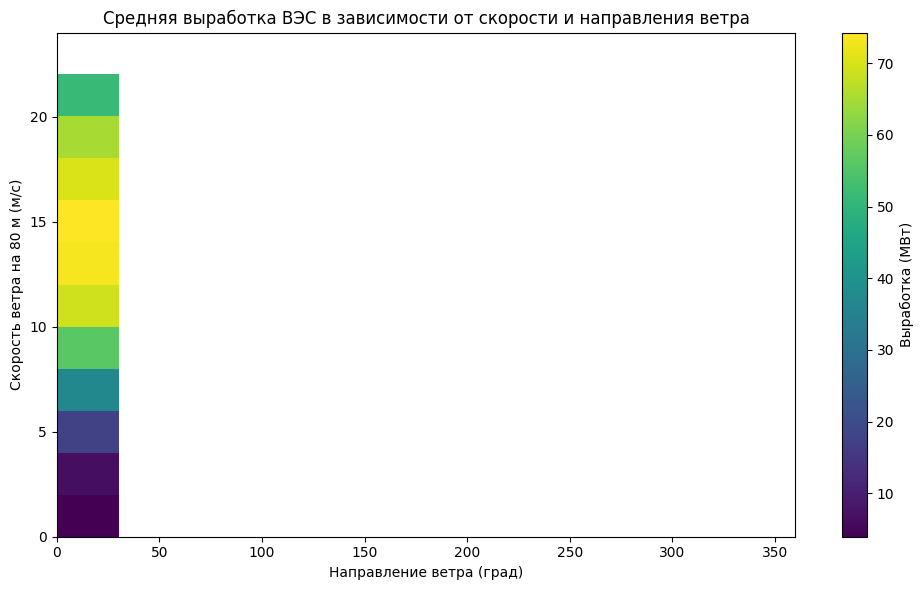

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('train_dataset.csv')

speed = train['wind_speed_80m']
# направление в радианах → градусы
direction_deg = train['wind_direction_80m'] * 180 / np.pi
power = train['Выработка. Результирующий расчет']

# Бинаризация
speed_bins = np.arange(0, 26, 2)          # 0..24 м/с
dir_bins = np.arange(0, 361, 30)          # 0..360°

speed_idx = np.digitize(speed, speed_bins) - 1
dir_idx = np.digitize(direction_deg, dir_bins) - 1

power_matrix = np.full((len(speed_bins)-1, len(dir_bins)-1), np.nan)
count_matrix = np.zeros_like(power_matrix)

for i in range(len(speed)):
    si = speed_idx[i]
    di = dir_idx[i]
    if 0 <= si < power_matrix.shape[0] and 0 <= di < power_matrix.shape[1]:
        if np.isnan(power_matrix[si, di]):
            power_matrix[si, di] = 0.0
        power_matrix[si, di] += power.iloc[i]
        count_matrix[si, di] += 1

with np.errstate(divide='ignore', invalid='ignore'):
    power_matrix = power_matrix / count_matrix

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(power_matrix, origin='lower', aspect='auto',
               extent=[dir_bins[0], dir_bins[-1], speed_bins[0], speed_bins[-1]],
               cmap='viridis')
ax.set_xlabel('Направление ветра (град)')
ax.set_ylabel('Скорость ветра на 80 м (м/с)')
ax.set_title('Средняя выработка ВЭС в зависимости от скорости и направления ветра')
fig.colorbar(im, label='Выработка (МВт)')
plt.tight_layout()
plt.show()

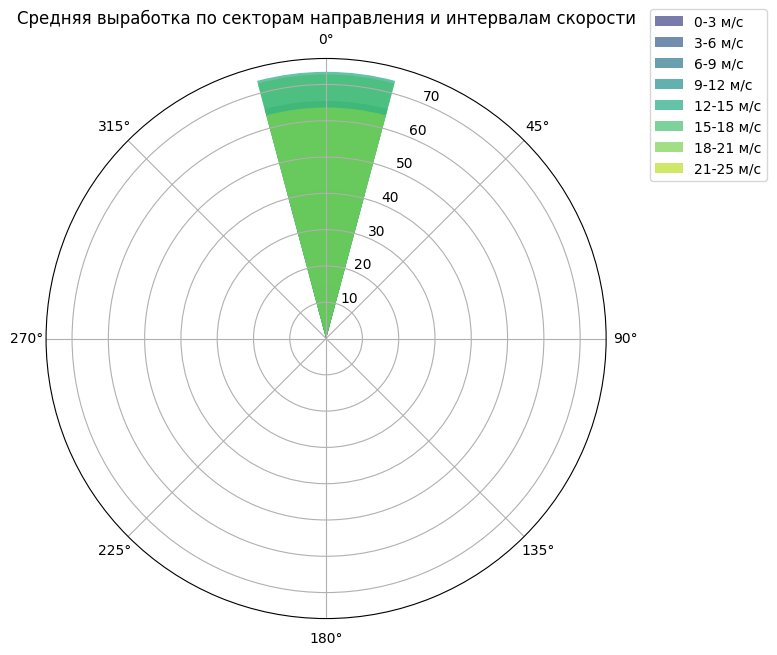

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

train = pd.read_csv('train_dataset.csv')

speed = train['wind_speed_80m']
direction_deg = train['wind_direction_80m'] * 180 / np.pi
power = train['Выработка. Результирующий расчет']

dir_sectors = np.arange(0, 360, 30)
speed_intervals = [0, 3, 6, 9, 12, 15, 18, 21, 25]

rose_matrix = np.zeros((len(speed_intervals)-1, len(dir_sectors)))
for i, (s_low, s_high) in enumerate(zip(speed_intervals[:-1], speed_intervals[1:])):
    for j, d_low in enumerate(dir_sectors):
        d_high = d_low + 30
        mask = (speed >= s_low) & (speed < s_high) & (direction_deg >= d_low) & (direction_deg < d_high)
        if mask.sum() > 0:
            rose_matrix[i, j] = power[mask].mean()
        else:
            rose_matrix[i, j] = 0.0   # на случай пустого сектора

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)
theta = np.linspace(0, 2*np.pi, len(dir_sectors), endpoint=False)
width = 2*np.pi / len(dir_sectors)
colors = cm.viridis(np.linspace(0.2, 0.9, len(speed_intervals)-1))

for i in range(len(speed_intervals)-1):
    ax.bar(theta, rose_matrix[i], width=width, bottom=0.0,
           color=colors[i], alpha=0.7, label=f'{speed_intervals[i]}-{speed_intervals[i+1]} м/с')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Средняя выработка по секторам направления и интервалам скорости')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Код ниже с наилучшим результатом 10,122

In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

# 2. Целевая и время
target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
valid[time_col] = pd.to_datetime(valid[time_col])
train = train.sort_values(time_col)

for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']]
feature_cols = [c for c in feature_cols if c in valid.columns]

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    X = X.fillna(X.median())

# ===== БЛОК КРОСС-ВАЛИДАЦИИ =====
N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
fold_errors = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]
    
    model_cv = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    model_cv.fit(X_tr, y_tr)
    preds = model_cv.predict(X_v)
    
    mae_mw = np.mean(np.abs(y_v - preds))
    fold_error_pct = mae_mw / N_UST * 100
    fold_errors.append(fold_error_pct)

fold_errors = np.array(fold_errors)
mean_err = fold_errors.mean()
std_err = fold_errors.std(ddof=1)
print(f"\n===== Кросс-валидация ({n_splits} фолдов) =====")
print(f"Ошибки по фолдам: {[f'{e:.2f}%' for e in fold_errors]}")
print(f"Средняя ошибка: {mean_err:.2f}%")
print(f"Стандартное отклонение: {std_err:.2f}%")
print(f"Диапазон ±3σ: от {mean_err - 3*std_err:.2f}% до {mean_err + 3*std_err:.2f}%")
# ===== КОНЕЦ БЛОКА ОЦЕНКИ =====

# 6. Финальное обучение на всех данных
final_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
final_model.fit(X, y)

# 7. Предсказание для valid
valid_data = valid[feature_cols].fillna(X.median())
preds = final_model.predict(valid_data)

# Сохранение с заголовком 'выработка'
pd.DataFrame({'выработка': preds}).to_csv('solverdataH.csv', index=False)
print("\n✅ solverdataH.csv сохранён (с заголовком 'выработка')")


===== Кросс-валидация (5 фолдов) =====
Ошибки по фолдам: ['11.20%', '11.31%', '11.05%', '9.93%', '9.41%']
Средняя ошибка: 10.58%
Стандартное отклонение: 0.86%
Диапазон ±3σ: от 8.00% до 13.15%

✅ solverdataH.csv сохранён (с заголовком 'выработка')


In [ ]:
Не удалять код выше - пока основа решения

In [49]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid преобразуем время, но НЕ сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# Признаки: только время (как в твоём успешном коде)
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']]
feature_cols = [c for c in feature_cols if c in valid.columns]

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из трейна
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 2. Подбор max_depth
N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

depths_to_try = [8, 10, 12, 15, 18, 20, 25]
best_depth = None
best_error = np.inf

print("Подбор max_depth:")
for depth in depths_to_try:
    fold_errors = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]
        model = RandomForestRegressor(n_estimators=100, max_depth=depth,
                                      random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        mae = np.mean(np.abs(y_v - preds))
        fold_errors.append(mae / N_UST * 100)
    avg_err = np.mean(fold_errors)
    print(f"  max_depth={depth}: средняя ошибка {avg_err:.2f}%")
    if avg_err < best_error:
        best_error = avg_err
        best_depth = depth

print(f"\nЛучший max_depth: {best_depth} (кросс-валидация: {best_error:.2f}%)")

# 3. Финальное обучение с лучшим depth
final_model = RandomForestRegressor(n_estimators=100, max_depth=best_depth,
                                    random_state=42, n_jobs=-1)
final_model.fit(X, y)

# 4. Предсказание для valid
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

preds = final_model.predict(valid_data)
preds = np.clip(preds, 0, None)   # убираем отрицательные

# 5. Сохранение
pd.DataFrame({'выработка': preds}).to_csv('solverdataHigher.csv', index=False)
print(f"✅ solverdataHigher.csv сохранён (строк: {len(preds)})")

Подбор max_depth:
  max_depth=8: средняя ошибка 10.43%
  max_depth=10: средняя ошибка 10.44%
  max_depth=12: средняя ошибка 10.50%
  max_depth=15: средняя ошибка 10.58%
  max_depth=18: средняя ошибка 10.61%
  max_depth=20: средняя ошибка 10.62%
  max_depth=25: средняя ошибка 10.62%

Лучший max_depth: 8 (кросс-валидация: 10.43%)
✅ solverdataHigher.csv сохранён (строк: 2126)


In [ ]:
Выше - на сайте 9,76%

In [50]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid: преобразуем время, но НЕ сортируем!
valid[time_col] = pd.to_datetime(valid[time_col])

# 2. Признаки: время + два физических (куб скорости и мощность)
for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Куб скорости на рабочей высоте 80 м
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    # Удельная мощность ветра (если есть давление и температура)
    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        # плотность ρ = P/(R·T)
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        # WPD = 0.5 * ρ * V^3
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

# 3. Отбор числовых признаков (все, что есть в обоих датасетах)
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# 4. Заполнение пропусков медианой из трейна
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 5. Подбор max_depth с новыми признаками
N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

depths_to_try = [8, 10, 12, 15, 18, 20, 25]
best_depth = None
best_error = np.inf

print("Подбор max_depth с кубом скорости и WPD:")
for depth in depths_to_try:
    fold_errors = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]
        model = RandomForestRegressor(n_estimators=100, max_depth=depth,
                                      random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        mae = np.mean(np.abs(y_v - preds))
        fold_errors.append(mae / N_UST * 100)
    avg_err = np.mean(fold_errors)
    print(f"  max_depth={depth}: средняя ошибка {avg_err:.2f}%")
    if avg_err < best_error:
        best_error = avg_err
        best_depth = depth

print(f"\nЛучший max_depth: {best_depth} (кросс-валидация: {best_error:.2f}%)")

# 6. Финальное обучение
final_model = RandomForestRegressor(n_estimators=100, max_depth=best_depth,
                                    random_state=42, n_jobs=-1)
final_model.fit(X, y)

# 7. Предсказание для valid
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

preds = final_model.predict(valid_data)
preds = np.clip(preds, 0, None)   # убираем отрицательные

# 8. Сохранение
pd.DataFrame({'выработка': preds}).to_csv('solverdata975.csv', index=False)
print(f"✅ solverdata975.csv сохранён (строк: {len(preds)})")

Признаков: 28
Подбор max_depth с кубом скорости и WPD:
  max_depth=8: средняя ошибка 10.48%
  max_depth=10: средняя ошибка 10.49%
  max_depth=12: средняя ошибка 10.54%
  max_depth=15: средняя ошибка 10.62%
  max_depth=18: средняя ошибка 10.66%
  max_depth=20: средняя ошибка 10.67%
  max_depth=25: средняя ошибка 10.67%

Лучший max_depth: 8 (кросс-валидация: 10.48%)
✅ solverdata975.csv сохранён (строк: 2126)


In [ ]:
Выше на сайте 9,75 - походу потолок для RF

In [ ]:
Ниже попробую LGBM

In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid: преобразуем время, но НЕ сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# 2. Признаки: время + куб скорости + мощность (как в последнем RF)
for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Куб скорости на 80 м
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    # Удельная мощность ветра (если есть давление и температура)
    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

# 3. Отбор числовых признаков
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из трейна
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 4. Подбор гиперпараметров LightGBM (max_depth и learning_rate)
N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

param_grid = [
    {'max_depth': d, 'learning_rate': lr}
    for d in [4, 6, 8, 10]
    for lr in [0.03, 0.05, 0.07]
]

best_params = None
best_error = np.inf

print("Подбор параметров LightGBM:")
for params in param_grid:
    fold_errors = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(
            n_estimators=500,
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            num_leaves=min(2**params['max_depth'] - 1, 31),
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_v, y_v)],
            eval_metric='mae',
            callbacks=[lgb.early_stopping(30, verbose=False)]
        )
        preds = model.predict(X_v)
        mae = np.mean(np.abs(y_v - preds))
        fold_errors.append(mae / N_UST * 100)

    avg_err = np.mean(fold_errors)
    print(f"  max_depth={params['max_depth']}, lr={params['learning_rate']}: {avg_err:.2f}%")
    if avg_err < best_error:
        best_error = avg_err
        best_params = params

print(f"\nЛучшие параметры: {best_params} (ошибка {best_error:.2f}%)")

# 5. Финальное обучение с лучшими параметрами
final_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    num_leaves=min(2**best_params['max_depth'] - 1, 31),
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_model.fit(X, y)

# 6. Предсказание для valid (порядок строк сохранён)
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

preds = final_model.predict(valid_data)
preds = np.clip(preds, 0, None)   # убираем отрицательные

# 7. Сохранение
pd.DataFrame({'выработка': preds}).to_csv('solverdata959.csv', index=False)
print(f"\n✅ solverdata959.csv сохранён. Строк: {len(preds)}")
print(f"Статистика: среднее={preds.mean():.3f} МВт, мин={preds.min():.3f} МВт, макс={preds.max():.3f} МВт")

Признаков: 28
Подбор параметров LightGBM:
  max_depth=4, lr=0.03: 10.48%
  max_depth=4, lr=0.05: 10.44%
  max_depth=4, lr=0.07: 10.44%
  max_depth=6, lr=0.03: 10.47%
  max_depth=6, lr=0.05: 10.43%
  max_depth=6, lr=0.07: 10.49%
  max_depth=8, lr=0.03: 10.53%
  max_depth=8, lr=0.05: 10.46%
  max_depth=8, lr=0.07: 10.41%
  max_depth=10, lr=0.03: 10.44%
  max_depth=10, lr=0.05: 10.43%
  max_depth=10, lr=0.07: 10.41%

Лучшие параметры: {'max_depth': 8, 'learning_rate': 0.07} (ошибка 10.41%)

✅ solverdata959.csv сохранён. Строк: 2126
Статистика: среднее=37.414 МВт, мин=0.000 МВт, макс=80.315 МВт


In [ ]:
Результат 9,59 для LGBM

In [ ]:
Ансамбль (RF + LGBM) - ниже

In [54]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid: преобразуем время, но НЕ сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# 2. Признаки (время + куб скорости + мощность)
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 3. Лучшие параметры (из предыдущих опытов)
best_depth_rf = 8          # дал 9.76%
best_params_lgb = {'max_depth': 8, 'learning_rate': 0.07, 'num_leaves': 31}   # пример, подставь свои реальные лучшие из вывода 9.59%

# 4. Кросс-валидация ансамбля
N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
ensemble_errors = []

for train_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    # LightGBM
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=best_params_lgb['max_depth'],
        learning_rate=best_params_lgb['learning_rate'],
        num_leaves=best_params_lgb['num_leaves'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_v, y_v)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    lgb_preds = lgb_model.predict(X_v)

    # Усреднение
    ensemble_preds = (rf_preds + lgb_preds) / 2
    mae = np.mean(np.abs(y_v - ensemble_preds))
    ensemble_errors.append(mae / N_UST * 100)

avg_ensemble_error = np.mean(ensemble_errors)
print(f"Ансамбль RF+LGBM средняя ошибка: {avg_ensemble_error:.2f}%")

# 5. Финальное обучение и предсказание для valid
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

# Обучаем обе модели на полном X
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=best_params_lgb['max_depth'],
    learning_rate=best_params_lgb['learning_rate'],
    num_leaves=best_params_lgb['num_leaves'],
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

ensemble_final = (rf_preds_final + lgb_preds_final) / 2
ensemble_final = np.clip(ensemble_final, 0, None)

# 6. Сохранение
pd.DataFrame({'выработка': ensemble_final}).to_csv('solverdataA952.csv', index=False)
print(f"✅ solverdataA952.csv сохранён (ансамбль). Строк: {len(ensemble_final)}")
print(f"Статистика: среднее={ensemble_final.mean():.3f} МВт, мин={ensemble_final.min():.3f} МВт, макс={ensemble_final.max():.3f} МВт")

Признаков: 28
Ансамбль RF+LGBM средняя ошибка: 10.38%
✅ solverdataA952.csv сохранён (ансамбль). Строк: 2126
Статистика: среднее=37.600 МВт, мин=0.718 МВт, макс=77.491 МВт


In [ ]:
Результат выше - 9,52

In [ ]:
Ниже попробую ансамбль (RF + LGBM + CatBoost)

In [57]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid: преобразуем время, но НЕ сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# 2. Признаки (время + куб скорости + мощность)
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 3. Лучшие параметры из предыдущих опытов (подставь свои)
best_depth_rf = 8
best_params_lgb = {'max_depth': 8, 'learning_rate': 0.07, 'num_leaves': 31}

# Параметры CatBoost (умеренные, чтобы не переобучаться)
cat_params = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# 4. Кросс-валидация ансамбля из трёх моделей
N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
ensemble_errors = []

for train_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    # LightGBM
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=best_params_lgb['max_depth'],
        learning_rate=best_params_lgb['learning_rate'],
        num_leaves=best_params_lgb['num_leaves'],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_v, y_v)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    lgb_preds = lgb_model.predict(X_v)

    # CatBoost
    cat_model = CatBoostRegressor(**cat_params)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v), early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    # Усреднение трёх прогнозов
    ensemble_preds = (rf_preds + lgb_preds + cat_preds) / 3
    mae = np.mean(np.abs(y_v - ensemble_preds))
    ensemble_errors.append(mae / N_UST * 100)

avg_ensemble_error = np.mean(ensemble_errors)
print(f"Ансамбль RF+LGBM+CatBoost средняя ошибка: {avg_ensemble_error:.2f}%")

# 5. Финальное обучение на всех данных
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

# Random Forest
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

# LightGBM
lgb_final = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=best_params_lgb['max_depth'],
    learning_rate=best_params_lgb['learning_rate'],
    num_leaves=best_params_lgb['num_leaves'],
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

# CatBoost
cat_final = CatBoostRegressor(**cat_params)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

# Ансамбль
ensemble_final = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
ensemble_final = np.clip(ensemble_final, 0, None)

# 6. Сохранение
pd.DataFrame({'выработка': ensemble_final}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён (тройной ансамбль). Строк: {len(ensemble_final)}")
print(f"Статистика: среднее={ensemble_final.mean():.3f} МВт, мин={ensemble_final.min():.3f} МВт, макс={ensemble_final.max():.3f} МВт")

Признаков: 28
Ансамбль RF+LGBM+CatBoost средняя ошибка: 10.30%
✅ solverdata.csv сохранён (тройной ансамбль). Строк: 2126
Статистика: среднее=37.621 МВт, мин=0.786 МВт, макс=77.552 МВт


In [ ]:
Выше - Результат 9,37

In [ ]:
Ниже тест

In [62]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

valid[time_col] = pd.to_datetime(valid[time_col])

# Признаки: время + куб + мощность + u80/v80 + shear
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    wd_rad = np.deg2rad(df['wind_direction_80m'])
    df['u80'] = df['wind_speed_80m'] * np.cos(wd_rad)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd_rad)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# Параметры, как в версии 9.37%, но с добавленными признаками
best_depth_rf = 18
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# Кросс-валидация
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v), early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    preds = (rf_preds + lgb_preds + cat_preds) / 3
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

avg_err = np.mean(ensemble_errors)
print(f"Ансамбль + u80/v80/shear: {avg_err:.2f}%")

# Финальное обучение и сохранение
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")

Признаков: 31
Ансамбль + u80/v80/shear: 10.43%
✅ solverdata.csv сохранён (2126 строк)


In [ ]:
Выше походу потолок.... (лучше не становится)

In [65]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid не сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# 2. Признаки: время + куб скорости + мощность
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 3. Лучшие параметры (9.37%)
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# 4. Кросс-валидация (для контроля)
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []
for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    preds = (rf_preds + lgb_preds + cat_preds) / 3
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

print(f"Кросс-валидация ансамбля: {np.mean(ensemble_errors):.2f}%")

# 5. Финальное обучение
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 28
Кросс-валидация ансамбля: 10.30%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.621 МВт, мин=0.786 МВт, макс=77.552 МВт


In [ ]:
Выше - результат на сайте 9,37% - по 3-му ансамбль зе энд думаю

In [ ]:
Ниже - RF + LGBM + CatBoost + MLP

In [66]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid не сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# 2. Признаки: время + куб скорости + мощность
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из трейна
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 3. Параметры моделей
best_depth_rf = 8        # твой лучший
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# MLPRegressor: два скрытых слоя, ранняя остановка
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,         # небольшая L2-регуляризация
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

# 4. Кросс-валидация с четырьмя моделями
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    # Масштабирование для MLP (важно!)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_v_scaled = scaler.transform(X_v)

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    # LightGBM
    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    # CatBoost
    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    # MLP
    mlp.fit(X_tr_scaled, y_tr)
    mlp_preds = mlp.predict(X_v_scaled)

    # Усреднение четырёх прогнозов
    preds = (rf_preds + lgb_preds + cat_preds + mlp_preds) / 4
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

print(f"Кросс-валидация ансамбля (RF+LGBM+CatBoost+MLP): {np.mean(ensemble_errors):.2f}%")

# 5. Финальное обучение на всех данных
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

# Масштабирование для MLP на всех данных
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
valid_scaled = scaler_full.transform(valid_data)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

mlp_final = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)
mlp_final.fit(X_scaled_full, y)
mlp_preds_final = mlp_final.predict(valid_scaled)

# Ансамбль четырёх моделей
final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final + mlp_preds_final) / 4
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 28
Кросс-валидация ансамбля (RF+LGBM+CatBoost+MLP): 10.34%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.594 МВт, мин=0.000 МВт, макс=78.935 МВт


In [ ]:
Выше - не сделало лучше 4-й ансамбль с результатом 9,42

In [67]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)
valid[time_col] = pd.to_datetime(valid[time_col])   # не сортируем!

# 2. Признаки (время + куб скорости + мощность)
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# 3. Параметры базовых моделей (лучшие для 9.37%)
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# 4. Кандидаты MLP (разные архитектуры и регуляризация)
mlp_candidates = [
    {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 32, 16), 'alpha': 0.0005, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0005, 'learning_rate_init': 0.0005},
    {'hidden_layer_sizes': (256, 128), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 64), 'alpha': 0.0001, 'learning_rate_init': 0.0005},
    {'hidden_layer_sizes': (100, 50), 'alpha': 0.001, 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (50, 25), 'alpha': 0.0005, 'learning_rate_init': 0.0005},
]

N_UST = 90.09
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# 5. Оценка каждого кандидата MLP в составе ансамбля
best_mlp_params = None
best_mlp_error = np.inf

print("Подбор MLP для ансамбля:")
for mlp_cfg in mlp_candidates:
    ensemble_errors = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

        # Масштабирование для MLP
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_v_scaled = scaler.transform(X_v)

        # Три базовые модели
        rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                   random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        rf_pred = rf.predict(X_v)

        lgb_model = lgb.LGBMRegressor(**params_lgb)
        lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                      eval_metric='mae',
                      callbacks=[lgb.early_stopping(30, verbose=False)])
        lgb_pred = lgb_model.predict(X_v)

        cat_model = CatBoostRegressor(**params_cat)
        cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                      early_stopping_rounds=30, verbose=False)
        cat_pred = cat_model.predict(X_v)

        # MLP с текущей конфигурацией
        mlp = MLPRegressor(
            hidden_layer_sizes=mlp_cfg['hidden_layer_sizes'],
            activation='relu',
            solver='adam',
            alpha=mlp_cfg['alpha'],
            batch_size=64,
            learning_rate_init=mlp_cfg['learning_rate_init'],
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=42
        )
        mlp.fit(X_tr_scaled, y_tr)
        mlp_pred = mlp.predict(X_v_scaled)

        # Ансамбль из 4 моделей
        preds = (rf_pred + lgb_pred + cat_pred + mlp_pred) / 4
        mae = np.mean(np.abs(y_v - preds))
        ensemble_errors.append(mae / N_UST * 100)

    avg_error = np.mean(ensemble_errors)
    print(f"  {mlp_cfg}: {avg_error:.4f}%")
    if avg_error < best_mlp_error:
        best_mlp_error = avg_error
        best_mlp_params = mlp_cfg

print(f"\nЛучший MLP: {best_mlp_params} (ошибка {best_mlp_error:.4f}%)")

# 6. Финальное обучение с лучшим MLP
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

# Масштабирование для финального MLP
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
valid_scaled = scaler_full.transform(valid_data)

# Базовые модели
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

# Лучший MLP
mlp_final = MLPRegressor(
    hidden_layer_sizes=best_mlp_params['hidden_layer_sizes'],
    activation='relu',
    solver='adam',
    alpha=best_mlp_params['alpha'],
    batch_size=64,
    learning_rate_init=best_mlp_params['learning_rate_init'],
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)
mlp_final.fit(X_scaled_full, y)
mlp_preds_final = mlp_final.predict(valid_scaled)

# Ансамбль
final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final + mlp_preds_final) / 4
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 28
Подбор MLP для ансамбля:
  {'hidden_layer_sizes': (64, 32), 'alpha': 0.001, 'learning_rate_init': 0.001}: 10.3439%
  {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}: 10.2873%
  {'hidden_layer_sizes': (64, 32, 16), 'alpha': 0.0005, 'learning_rate_init': 0.001}: 10.3227%
  {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0005, 'learning_rate_init': 0.0005}: 10.2685%
  {'hidden_layer_sizes': (256, 128), 'alpha': 0.001, 'learning_rate_init': 0.001}: 10.3719%
  {'hidden_layer_sizes': (64, 64), 'alpha': 0.0001, 'learning_rate_init': 0.0005}: 10.2623%
  {'hidden_layer_sizes': (100, 50), 'alpha': 0.001, 'learning_rate_init': 0.001}: 10.2477%
  {'hidden_layer_sizes': (50, 25), 'alpha': 0.0005, 'learning_rate_init': 0.0005}: 10.2457%

Лучший MLP: {'hidden_layer_sizes': (50, 25), 'alpha': 0.0005, 'learning_rate_init': 0.0005} (ошибка 10.2457%)
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.517 МВт, мин=0.258 МВт, макс=78.156 МВт


In [ ]:
Выше получили 9,39 - походу максимум для 4-го ансамбля

In [68]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Загрузка
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем train по времени, valid не трогаем
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

valid[time_col] = pd.to_datetime(valid[time_col])   # НЕ сортируем!

# 2. Признаки: время + куб скорости + мощность + компоненты + сдвиг
for df in [train, valid]:
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['ws80_cubed'] = df['wind_speed_80m'] ** 3

    # компоненты ветра
    wd_rad = np.deg2rad(df['wind_direction_80m'])
    df['u80'] = df['wind_speed_80m'] * np.cos(wd_rad)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd_rad)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

# 3. Лаги (только для train и valid отдельно, без переноса между ними)
for df in [train, valid]:
    # лаги скорости ветра на 80 м
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)
    # лаги направления (через sin/cos, чтобы избежать скачков 0-360)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(np.deg2rad(wd_lag1))
    df['wd80_lag1_cos'] = np.cos(np.deg2rad(wd_lag1))

# Удаляем строки с NaN у train (первые 3 строки после лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# Для valid заполним NaN медианой из train позже

# 4. Отбор числовых признаков
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# 5. Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

# Применяем те же медианы к valid (лаговые NaN будут заполнены)
if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

# 6. Лучшие параметры (9.37%)
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# 7. Кросс-валидация
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    preds = (rf_preds + lgb_preds + cat_preds) / 3
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

print(f"Кросс-валидация ансамбля с лагами: {np.mean(ensemble_errors):.2f}%")

# 8. Финальное обучение на всех train
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 36
Кросс-валидация ансамбля с лагами: 10.36%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.621 МВт, мин=0.997 МВт, макс=77.363 МВт


In [ ]:
Рекорд 3-й ансамбль с лагами (учет возможного сохранения скорости ветра) - 9,34%

In [ ]:
Ниже уточнил параметры каждого генератора

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# ----------------------------
# 0. Новые константы турбины
# ----------------------------
N_TURBINES = 26
P_MAX_PER_TURBINE = 3.465  # МВт
N_UST_TOTAL = N_TURBINES * P_MAX_PER_TURBINE  # 90.09 МВт
CUT_IN_WIND_SPEED = 3.0    # м/с
RATED_WIND_SPEED = 10.3    # м/с
CUT_OUT_WIND_SPEED = 25.0  # м/с

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid НЕ сортируем!
valid[time_col] = pd.to_datetime(valid[time_col])

# ----------------------------
# 2. Генерация признаков (старые + новые физические)
# ----------------------------
for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd_rad = np.deg2rad(df['wind_direction_80m'])
    df['u80'] = df['wind_speed_80m'] * np.cos(wd_rad)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd_rad)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(np.deg2rad(wd_lag1))
    df['wd80_lag1_cos'] = np.cos(np.deg2rad(wd_lag1))

    # -- НОВЫЙ ПРИЗНАК: Теоретическая мощность одной турбины --
    ws = df['wind_speed_80m'].values
    theoretical_power = np.zeros_like(ws)
    reg_range = (ws >= CUT_IN_WIND_SPEED) & (ws < RATED_WIND_SPEED)
    theoretical_power[reg_range] = P_MAX_PER_TURBINE * ((ws[reg_range] - CUT_IN_WIND_SPEED) / (RATED_WIND_SPEED - CUT_IN_WIND_SPEED))**3
    rated_range = (ws >= RATED_WIND_SPEED) & (ws <= CUT_OUT_WIND_SPEED)
    theoretical_power[rated_range] = P_MAX_PER_TURBINE
    df['theoretical_power_per_turbine'] = theoretical_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Масштабирование целевой переменной (на одну турбину)
# ----------------------------
y_per_turbine = train[target_col] / N_TURBINES

# ----------------------------
# 4. Отбор признаков и заполнение пропусков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

if medians is not None:
    valid_data = valid[feature_cols].fillna(medians)
else:
    valid_data = valid[feature_cols]

# ----------------------------
# 5. Параметры моделей (9.34%)
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 6. Кросс-валидация (для контроля)
# ----------------------------
N_UST_PER_TURBINE = P_MAX_PER_TURBINE
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y_per_turbine.iloc[tr_idx], y_per_turbine.iloc[val_idx]

    # RF
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    # LGBM
    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    # CatBoost
    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    # Простое усреднение (для одной турбины)
    preds_per_turbine = (rf_preds + lgb_preds + cat_preds) / 3
    preds_total = preds_per_turbine * N_TURBINES
    y_v_total = y_v * N_TURBINES
    ensemble_errors.append(np.mean(np.abs(y_v_total - preds_total)) / N_UST_TOTAL * 100)

print(f"Кросс-валидация ансамбля (физика): {np.mean(ensemble_errors):.2f}%")

# ----------------------------
# 7. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y_per_turbine)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y_per_turbine)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y_per_turbine, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

# Усреднение для одной турбины
final_preds_per_turbine = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3

# Жёсткий клиппинг на основе физики
valid_wind_speed = valid_data['wind_speed_80m'].values
mask_low = valid_wind_speed < CUT_IN_WIND_SPEED
mask_high = valid_wind_speed > CUT_OUT_WIND_SPEED
final_preds_per_turbine[mask_low] = 0.0
final_preds_per_turbine[mask_high] = 0.0
final_preds_per_turbine = np.clip(final_preds_per_turbine, 0, P_MAX_PER_TURBINE)

# Умножаем на 26 для получения общей мощности станции
final_preds_total = final_preds_per_turbine * N_TURBINES

pd.DataFrame({'выработка': final_preds_total}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds_total)} строк)")
print(f"Статистика: среднее={final_preds_total.mean():.3f} МВт, мин={final_preds_total.min():.3f} МВт, макс={final_preds_total.max():.3f} МВт")

Признаков: 36
Кросс-валидация ансамбля (физика): 10.35%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.003 МВт, мин=0.000 МВт, макс=77.602 МВт


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid НЕ сортируем
valid[time_col] = pd.to_datetime(valid[time_col])

# ----------------------------
# 2. Генерация признаков
# ----------------------------
# Параметры турбины (для теоретической мощности)
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd_rad = np.deg2rad(df['wind_direction_80m'])
    df['u80'] = df['wind_speed_80m'] * np.cos(wd_rad)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd_rad)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(np.deg2rad(wd_lag1))
    df['wd80_lag1_cos'] = np.cos(np.deg2rad(wd_lag1))

    # -- НОВЫЙ ПРИЗНАК: теоретическая мощность всей станции --
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]          # суммарная мощность, без деления на турбины

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Параметры моделей (9.34%)
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 5. Кросс-валидация
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    preds = (rf_preds + lgb_preds + cat_preds) / 3
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

print(f"Кросс-валидация с theory_power_total: {np.mean(ensemble_errors):.2f}%")

# ----------------------------
# 6. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata926.csv', index=False)
print(f"✅ solverdata926.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Кросс-валидация с theory_power_total: 10.34%
✅ solverdata926.csv сохранён (2126 строк)
Статистика: среднее=37.690 МВт, мин=1.053 МВт, макс=77.322 МВт


In [ ]:
Выше рекорд загрузки - 9,26%

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)          # только train

valid[time_col] = pd.to_datetime(valid[time_col])   # НЕ сортируем!

# ----------------------------
# 2. Генерация признаков (как в 9.26%)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd_rad = np.deg2rad(df['wind_direction_80m'])
    df['u80'] = df['wind_speed_80m'] * np.cos(wd_rad)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd_rad)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги скорости
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # Лаги направления (только 1 час)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(np.deg2rad(wd_lag1))
    df['wd80_lag1_cos'] = np.cos(np.deg2rad(wd_lag1))

    # Теоретическая мощность станции
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Параметры моделей (9.26% + усиление CatBoost)
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 1000,        # было 500
    'learning_rate': 0.05,
    'depth': 8,                # было 6
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 5. Кросс-валидация
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    preds = (rf_preds + lgb_preds + cat_preds) / 3
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

print(f"Кросс-валидация с усиленным CatBoost: {np.mean(ensemble_errors):.2f}%")

# ----------------------------
# 6. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Кросс-валидация с усиленным CatBoost: 10.38%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.567 МВт, мин=0.344 МВт, макс=77.712 МВт


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from catboost import CatBoostRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)          # сортируем train

valid[time_col] = pd.to_datetime(valid[time_col])   # НЕ сортируем valid!
N_valid = len(valid)

# ----------------------------
# 2. Генерация признаков (как в 9.26%)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd_rad = np.deg2rad(df['wind_direction_80m'])
    df['u80'] = df['wind_speed_80m'] * np.cos(wd_rad)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd_rad)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги скорости
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # Лаг направления (1 час)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(np.deg2rad(wd_lag1))
    df['wd80_lag1_cos'] = np.cos(np.deg2rad(wd_lag1))

    # Теоретическая мощность станции
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
num_feat = len(feature_cols)
print(f"Признаков: {num_feat}")

X = train[feature_cols]
y = train[target_col].values.reshape(-1, 1)

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
    valid_data = valid[feature_cols].fillna(medians)
else:
    medians = None
    valid_data = valid[feature_cols].copy()

# ----------------------------
# 4. Ансамбль 9.26% (обучаем сразу на всём трейне для заполнения окон)
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.07,
    'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
}
params_cat = {
    'iterations': 500, 'learning_rate': 0.05, 'depth': 6,
    'random_seed': 42, 'verbose': False
}

rf_base = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=42, n_jobs=-1)
rf_base.fit(X, y.ravel())
rf_pred = rf_base.predict(valid_data)

lgb_base = lgb.LGBMRegressor(**params_lgb)
lgb_base.fit(X, y.ravel())
lgb_pred = lgb_base.predict(valid_data)

cat_base = CatBoostRegressor(**params_cat)
cat_base.fit(X, y.ravel(), verbose=False)
cat_pred = cat_base.predict(valid_data)

baseline_ensemble = (rf_pred + lgb_pred + cat_pred) / 3
baseline_ensemble = np.clip(baseline_ensemble, 0, None)

# ----------------------------
# 5. Подготовка окон для GRU (48 часов)
# ----------------------------
LOOKBACK = 48

def create_sequences(data, target=None):
    Xs = []
    for i in range(LOOKBACK, len(data)):
        Xs.append(data[i-LOOKBACK:i])
    if target is not None:
        return np.array(Xs), target[LOOKBACK:]
    return np.array(Xs)

X_values = X.values
y_values = y

X_seq, y_seq = create_sequences(X_values, y_values)

# Для valid создаём последовательности
X_valid_values = valid_data.values
X_valid_seq = create_sequences(X_valid_values)   # (N_valid - LOOKBACK, LOOKBACK, num_feat)

# ----------------------------
# 6. Масштабирование для нейросети
# ----------------------------
scaler_X = StandardScaler()
X_seq_flat = X_seq.reshape(-1, num_feat)
scaler_X.fit(X_seq_flat)

X_scaled = scaler_X.transform(X_seq_flat).reshape(-1, LOOKBACK, num_feat)
X_valid_flat = X_valid_seq.reshape(-1, num_feat)
X_valid_scaled = scaler_X.transform(X_valid_flat).reshape(-1, LOOKBACK, num_feat)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_seq)

# Тензоры
X_train_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_scaled, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid_scaled, dtype=torch.float32)

# ----------------------------
# 7. GRU + Attention
# ----------------------------
class GRUAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, bidirectional=True, dropout=dropout)
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 1),
            nn.Tanh()
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gru_out, _ = self.gru(x)            # (batch, seq, hidden*2)
        attn_weights = self.attention(gru_out)  # (batch, seq, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(gru_out * attn_weights, dim=1)  # (batch, hidden*2)
        context = self.dropout(context)
        out = self.fc(context)
        return out

model = GRUAttention(num_feat, hidden_dim=64, num_layers=2, dropout=0.2)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Обучение
epochs = 150
batch_size = 64
dataset = TensorDataset(X_train_tensor, y_train_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Обучение GRU+Attention...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for Xb, yb in loader:
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(Xb)
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss: {train_loss/len(dataset):.4f}")

# ----------------------------
# 8. Предсказания GRU для валидации (полная длина)
# ----------------------------
model.eval()
with torch.no_grad():
    gru_preds_scaled = model(X_valid_tensor).numpy()
gru_preds = scaler_y.inverse_transform(gru_preds_scaled).flatten()

# Заполняем первые LOOKBACK часов ансамблем 9.26%
gru_full_preds = np.empty(N_valid)
gru_full_preds[:LOOKBACK] = baseline_ensemble[:LOOKBACK]
gru_full_preds[LOOKBACK:] = gru_preds

# ----------------------------
# 9. Блендинг: подбор весов (ансамбль 9.26% + GRU)
# ----------------------------
tscv = TimeSeriesSplit(n_splits=5)
meta_train = np.zeros((len(X), 2))   # ансамбль, GRU

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y[tr_idx], y[val_idx]

    # Ансамбль 9.26% на фолде
    rf_cv = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf, random_state=42, n_jobs=-1)
    rf_cv.fit(X_tr, y_tr.ravel())
    rf_preds_cv = rf_cv.predict(X_v)

    lgb_cv = lgb.LGBMRegressor(**params_lgb)
    lgb_cv.fit(X_tr, y_tr.ravel(), eval_set=[(X_v, y_v.ravel())],
               eval_metric='mae', callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds_cv = lgb_cv.predict(X_v)

    cat_cv = CatBoostRegressor(**params_cat)
    cat_cv.fit(X_tr, y_tr.ravel(), eval_set=(X_v, y_v.ravel()),
               early_stopping_rounds=30, verbose=False)
    cat_preds_cv = cat_cv.predict(X_v)

    ensemble_fold = (rf_preds_cv + lgb_preds_cv + cat_preds_cv) / 3
    meta_train[val_idx, 0] = ensemble_fold

    # GRU на фолде (быстрое обучение)
    X_tr_values = X_tr.values
    X_v_values = X_v.values
    X_tr_seq_fold, y_tr_seq_fold = create_sequences(X_tr_values, y_tr)
    X_v_seq_fold = create_sequences(X_v_values)

    # Масштабирование fold
    scaler_fold_X = StandardScaler()
    X_tr_flat = X_tr_seq_fold.reshape(-1, num_feat)
    scaler_fold_X.fit(X_tr_flat)
    X_tr_scaled_fold = scaler_fold_X.transform(X_tr_flat).reshape(-1, LOOKBACK, num_feat)
    X_v_scaled_fold = scaler_fold_X.transform(X_v_seq_fold.reshape(-1, num_feat)).reshape(-1, LOOKBACK, num_feat)

    scaler_fold_y = StandardScaler()
    y_tr_scaled_fold = scaler_fold_y.fit_transform(y_tr_seq_fold.reshape(-1, 1))

    # Быстрая GRU
    gru_fold = GRUAttention(num_feat, hidden_dim=32, num_layers=1, dropout=0.1)
    opt = torch.optim.Adam(gru_fold.parameters(), lr=0.001)
    crit = nn.L1Loss()
    X_fold_tensor = torch.tensor(X_tr_scaled_fold, dtype=torch.float32)
    y_fold_tensor = torch.tensor(y_tr_scaled_fold, dtype=torch.float32)
    fold_loader = DataLoader(TensorDataset(X_fold_tensor, y_fold_tensor), batch_size=64, shuffle=True)

    for _ in range(50):
        for Xb, yb in fold_loader:
            opt.zero_grad()
            loss = crit(gru_fold(Xb), yb)
            loss.backward()
            opt.step()

    gru_fold.eval()
    with torch.no_grad():
        preds_gru_scaled = gru_fold(torch.tensor(X_v_scaled_fold, dtype=torch.float32)).numpy()
    preds_gru_fold = scaler_fold_y.inverse_transform(preds_gru_scaled).flatten()

    # Заполняем начало ансамблем (как в финале)
    baseline_fold = ensemble_fold
    gru_full_fold = np.concatenate([baseline_fold[:LOOKBACK], preds_gru_fold])
    meta_train[val_idx, 1] = gru_full_fold

# ----------------------------
# 10. Подбор весов для блендинга (ансамбль vs GRU)
# ----------------------------
best_weights = None
best_cv_error = np.inf

print("Подбор весов для блендинга (ансамбль + GRU)...")
for w1 in range(0, 11):
    w2 = 10 - w1
    weights = np.array([w1, w2]) / 10.0
    cv_errors = []
    for tr_idx, val_idx in tscv.split(meta_train):
        meta_v = meta_train[val_idx]
        y_v = y[val_idx]
        blended = np.dot(meta_v, weights)
        mae = np.mean(np.abs(y_v - blended))
        cv_errors.append(mae / 90.09 * 100)
    avg_err = np.mean(cv_errors)
    if avg_err < best_cv_error:
        best_cv_error = avg_err
        best_weights = weights.copy()

print(f"Лучшие веса: Ансамбль={best_weights[0]:.2f}, GRU={best_weights[1]:.2f}")
print(f"Ошибка блендинга на кросс-валидации: {best_cv_error:.4f}%")

# ----------------------------
# 11. Финальный прогноз с оптимальными весами
# ----------------------------
final_preds = best_weights[0] * baseline_ensemble + best_weights[1] * gru_full_preds
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Обучение GRU+Attention...
Epoch 20/150 | loss: 0.2785
Epoch 40/150 | loss: 0.2211
Epoch 60/150 | loss: 0.1916
Epoch 80/150 | loss: 0.1737
Epoch 100/150 | loss: 0.1613
Epoch 120/150 | loss: 0.1528
Epoch 140/150 | loss: 0.1458


c:\Users\DIPY\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\nn\modules\rnn.py:1356: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
c:\Users\DIPY\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\nn\modules\rnn.py:1356: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
c:\Users\DIPY\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\nn\modules\rnn.py:1356: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)
c:\Users\DIPY\AppData\Local\Python\pythoncore-3.14-64\Lib\

Подбор весов для блендинга (ансамбль + GRU)...
Лучшие веса: Ансамбль=0.50, GRU=0.50
Ошибка блендинга на кросс-валидации: 29.9705%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.258 МВт, мин=0.052 МВт, макс=79.347 МВт


In [ ]:
Выше - Оставлю нейросетевой метод - 10,27

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid НЕ сортируем!
valid[time_col] = pd.to_datetime(valid[time_col])

# ----------------------------
# 2. Генерация признаков (исправленные радианы)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # -- Время --
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # -- Физика --
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    # Направление уже в радианах! Никаких deg2rad.
    wd = df['wind_direction_80m']
    df['u80'] = df['wind_speed_80m'] * np.cos(wd)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # -- Лаги скорости --
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # -- Лаги направления (1 час) в радианах --
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(wd_lag1)
    df['wd80_lag1_cos'] = np.cos(wd_lag1)

    # -- Теоретическая мощность станции --
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Параметры моделей (9.26%)
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 5. Кросс-валидация
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
ensemble_errors = []

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_preds = rf.predict(X_v)

    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    lgb_preds = lgb_model.predict(X_v)

    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    cat_preds = cat_model.predict(X_v)

    preds = (rf_preds + lgb_preds + cat_preds) / 3
    ensemble_errors.append(np.mean(np.abs(y_v - preds)) / N_UST * 100)

print(f"Кросс-валидация с исправленными радианами: {np.mean(ensemble_errors):.2f}%")

# ----------------------------
# 6. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (rf_preds_final + lgb_preds_final + cat_preds_final) / 3
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Кросс-валидация с исправленными радианами: 10.37%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.624 МВт, мин=0.716 МВт, макс=77.481 МВт


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid НЕ сортируем!
valid[time_col] = pd.to_datetime(valid[time_col])

# ----------------------------
# 2. Генерация признаков (как в 9.26%, исправленные радианы)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd = df['wind_direction_80m']   # радианы
    df['u80'] = df['wind_speed_80m'] * np.cos(wd)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги скорости
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # Лаги направления (1 час)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(wd_lag1)
    df['wd80_lag1_cos'] = np.cos(wd_lag1)

    # Теоретическая мощность станции
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Параметры моделей
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 5. Out-of-fold предсказания для подбора весов
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
meta_train = np.zeros((len(X), 3))  # RF, LGBM, CatBoost

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    # RF
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    meta_train[val_idx, 0] = rf.predict(X_v)

    # LGBM
    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    meta_train[val_idx, 1] = lgb_model.predict(X_v)

    # CatBoost
    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    meta_train[val_idx, 2] = cat_model.predict(X_v)

# ----------------------------
# 6. Подбор весов (перебор с шагом 0.05)
# ----------------------------
best_weights = None
best_cv_error = np.inf

print("Подбор весов для ансамбля...")
for w1 in range(0, 21):          # 0, 1, ..., 20 (шаг 5%)
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0

        cv_errors = []
        for tr_idx, val_idx in tscv.split(meta_train):
            meta_v = meta_train[val_idx]
            y_v = y.iloc[val_idx]
            ensemble_pred = np.dot(meta_v, weights)
            mae = np.mean(np.abs(y_v - ensemble_pred))
            cv_errors.append(mae / N_UST * 100)

        avg_err = np.mean(cv_errors)
        if avg_err < best_cv_error:
            best_cv_error = avg_err
            best_weights = weights.copy()

print(f"Лучшие веса: RF={best_weights[0]:.2f}, LGBM={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"Ошибка блендинга на кросс-валидации: {best_cv_error:.4f}%")

# ----------------------------
# 7. Финальное обучение с лучшими весами
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (best_weights[0] * rf_preds_final +
               best_weights[1] * lgb_preds_final +
               best_weights[2] * cat_preds_final)
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Подбор весов для ансамбля...
Лучшие веса: RF=0.35, LGBM=0.00, CatBoost=0.65
Ошибка блендинга на кросс-валидации: 10.3476%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.550 МВт, мин=1.082 МВт, макс=77.084 МВт


In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid НЕ сортируем!
valid[time_col] = pd.to_datetime(valid[time_col])

# ----------------------------
# 2. Генерация признаков (как в 9.26%, исправленные радианы)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd = df['wind_direction_80m']   # радианы
    df['u80'] = df['wind_speed_80m'] * np.cos(wd)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги скорости
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # Лаги направления (1 час)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(wd_lag1)
    df['wd80_lag1_cos'] = np.cos(wd_lag1)

    # Теоретическая мощность станции
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Параметры моделей
# ----------------------------
best_depth_rf = 8
params_lgb = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.07,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}
# Для XGBoost передаём early_stopping_rounds в конструктор – совместимо со всеми версиями
params_xgb = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbosity': 0,
    'early_stopping_rounds': 30       # для версий <1.6.0
}

# ----------------------------
# 5. Out-of-fold предсказания (4 модели)
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
meta_train = np.zeros((len(X), 4))  # RF, LGBM, CAT, XGB

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    meta_train[val_idx, 0] = rf.predict(X_v)

    # LightGBM
    lgb_model = lgb.LGBMRegressor(**params_lgb)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  eval_metric='mae',
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    meta_train[val_idx, 1] = lgb_model.predict(X_v)

    # CatBoost
    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    meta_train[val_idx, 2] = cat_model.predict(X_v)

    # XGBoost
    xgb_model = xgb.XGBRegressor(**params_xgb)
    # Передаём eval_set для ранней остановки (старые версии берут из конструктора)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    meta_train[val_idx, 3] = xgb_model.predict(X_v)

# ----------------------------
# 6. Подбор весов (перебор с шагом 0.05)
# ----------------------------
best_weights = None
best_cv_error = np.inf

print("Подбор весов для ансамбля (4 модели)...")
for w1 in range(0, 21):          # 0..20 (шаг 5%)
    for w2 in range(0, 21 - w1):
        for w3 in range(0, 21 - w1 - w2):
            w4 = 20 - w1 - w2 - w3
            weights = np.array([w1, w2, w3, w4]) / 20.0

            cv_errors = []
            for tr_idx, val_idx in tscv.split(meta_train):
                meta_v = meta_train[val_idx]
                y_v = y.iloc[val_idx]
                ensemble_pred = np.dot(meta_v, weights)
                mae = np.mean(np.abs(y_v - ensemble_pred))
                cv_errors.append(mae / N_UST * 100)

            avg_err = np.mean(cv_errors)
            if avg_err < best_cv_error:
                best_cv_error = avg_err
                best_weights = weights.copy()

print(f"Лучшие веса: RF={best_weights[0]:.2f}, LGBM={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}, XGBoost={best_weights[3]:.2f}")
print(f"Ошибка блендинга на кросс-валидации: {best_cv_error:.4f}%")

# ----------------------------
# 7. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

lgb_final = lgb.LGBMRegressor(**params_lgb)
lgb_final.fit(X, y)
lgb_preds_final = lgb_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

# Для финала XGBoost используем те же параметры, но без early_stopping (или можно оставить – не страшно)
xgb_final = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, verbosity=0
)
xgb_final.fit(X, y)
xgb_preds_final = xgb_final.predict(valid_data)

# Взвешиваем
final_preds = (best_weights[0] * rf_preds_final +
               best_weights[1] * lgb_preds_final +
               best_weights[2] * cat_preds_final +
               best_weights[3] * xgb_preds_final)
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Подбор весов для ансамбля (4 модели)...
Лучшие веса: RF=0.35, LGBM=0.00, CatBoost=0.65, XGBoost=0.00
Ошибка блендинга на кросс-валидации: 10.3476%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.550 МВт, мин=1.082 МВт, макс=77.084 МВт


4 модели не помогли

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

# Сортируем только train
train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)

# valid НЕ сортируем!
valid[time_col] = pd.to_datetime(valid[time_col])

# ----------------------------
# 2. Генерация признаков (как в 9.26%, исправленные радианы)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd = df['wind_direction_80m']   # радианы
    df['u80'] = df['wind_speed_80m'] * np.cos(wd)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги скорости
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # Лаги направления (1 час)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(wd_lag1)
    df['wd80_lag1_cos'] = np.cos(wd_lag1)

    # Теоретическая мощность станции
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Параметры моделей
# ----------------------------
best_depth_rf = 8
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 5. Out-of-fold предсказания для RF и CatBoost
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
meta_train = np.zeros((len(X), 2))  # RF, CatBoost

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    meta_train[val_idx, 0] = rf.predict(X_v)

    # CatBoost
    cat_model = CatBoostRegressor(**params_cat)
    cat_model.fit(X_tr, y_tr, eval_set=(X_v, y_v),
                  early_stopping_rounds=30, verbose=False)
    meta_train[val_idx, 1] = cat_model.predict(X_v)

# ----------------------------
# 6. Подбор весов (перебор с шагом 0.05)
# ----------------------------
best_weights = None
best_cv_error = np.inf

print("Подбор весов для RF + CatBoost...")
for w1 in range(0, 21):          # 0..20 (шаг 5%)
    w2 = 20 - w1
    weights = np.array([w1, w2]) / 20.0

    cv_errors = []
    for tr_idx, val_idx in tscv.split(meta_train):
        meta_v = meta_train[val_idx]
        y_v = y.iloc[val_idx]
        ensemble_pred = np.dot(meta_v, weights)
        mae = np.mean(np.abs(y_v - ensemble_pred))
        cv_errors.append(mae / N_UST * 100)

    avg_err = np.mean(cv_errors)
    if avg_err < best_cv_error:
        best_cv_error = avg_err
        best_weights = weights.copy()

print(f"Лучшие веса: RF={best_weights[0]:.2f}, CatBoost={best_weights[1]:.2f}")
print(f"Ошибка блендинга на кросс-валидации: {best_cv_error:.4f}%")

# ----------------------------
# 7. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = (best_weights[0] * rf_preds_final +
               best_weights[1] * cat_preds_final)
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 37
Подбор весов для RF + CatBoost...
Лучшие веса: RF=0.35, CatBoost=0.65
Ошибка блендинга на кросс-валидации: 10.3476%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.550 МВт, мин=1.082 МВт, макс=77.084 МВт


Ниже - специфическое деление на режимы

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)          # только train

valid[time_col] = pd.to_datetime(valid[time_col])   # НЕ сортируем!

# ----------------------------
# 2. Генерация признаков (как в 9.26%)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # Время
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Физика
    df['ws80_cubed'] = df['wind_speed_80m'] ** 3
    wd = df['wind_direction_80m']   # радианы
    df['u80'] = df['wind_speed_80m'] * np.cos(wd)
    df['v80'] = df['wind_speed_80m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_80m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_80m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws80_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_80'] = df['wind_speed_120m'] - df['wind_speed_80m']

    # Лаги скорости
    df['ws80_lag1'] = df['wind_speed_80m'].shift(1)
    df['ws80_lag2'] = df['wind_speed_80m'].shift(2)
    df['ws80_lag3'] = df['wind_speed_80m'].shift(3)

    # Лаги направления (1 час)
    wd_lag1 = df['wind_direction_80m'].shift(1)
    df['wd80_lag1_sin'] = np.sin(wd_lag1)
    df['wd80_lag1_cos'] = np.cos(wd_lag1)

    # Теоретическая мощность станции
    ws = df['wind_speed_80m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws80_lag1','ws80_lag2','ws80_lag3','wd80_lag1_sin','wd80_lag1_cos'])

# ----------------------------
# 3. Отбор признаков для моделирования
# ----------------------------
feature_cols = [c for c in train.columns
                if c not in [target_col, time_col]
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков для модели: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 4. Признаки для кластеризации (физические)
# ----------------------------
cluster_features = [
    'wind_speed_80m', 'u80', 'v80',          # ветер
    'shear_120_80',                           # сдвиг
    'air_density',                            # плотность
    'wind_power_density',                     # удельная мощность
    'hour_sin', 'hour_cos',                   # время суток
    'month_sin', 'month_cos'                  # сезон
]

# Проверяем, что все есть
cluster_features = [c for c in cluster_features if c in X.columns]
print(f"Признаков для кластеризации: {len(cluster_features)}")

# Масштабируем для KMeans
scaler_km = StandardScaler()
X_km_train = scaler_km.fit_transform(X[cluster_features])

# ----------------------------
# 5. Подбор числа кластеров (по инерции или силуэту)
# ----------------------------
# Для простоты фиксируем 4 кластера (можно подобрать)
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
train['cluster'] = kmeans.fit_predict(X_km_train)

# Применяем тот же кластеризатор к valid
X_km_valid = scaler_km.transform(valid_data[cluster_features])
valid['cluster'] = kmeans.predict(X_km_valid)

print(f"Распределение кластеров в train: {train['cluster'].value_counts().to_dict()}")
print(f"Распределение кластеров в valid: {valid['cluster'].value_counts().to_dict()}")

# ----------------------------
# 6. Параметры моделей (как в 9.26%)
# ----------------------------
best_depth_rf = 16
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 7. Обучение отдельного ансамбля для каждого кластера
# ----------------------------
cluster_models = {}   # {cluster_id: (rf_model, cat_model, weight_rf, weight_cat)}

for cl in range(n_clusters):
    print(f"\nОбучаем модели для кластера {cl}...")
    mask = train['cluster'] == cl
    X_cl = X[mask]
    y_cl = y[mask]

    if len(X_cl) < 50:   # слишком мало данных – используем общую модель
        print(f"  Слишком мало данных, используем общую модель")
        rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                   random_state=42, n_jobs=-1)
        rf.fit(X, y)   # обучаем на всех данных
        cat = CatBoostRegressor(**params_cat)
        cat.fit(X, y, verbose=False)
        cluster_models[cl] = (rf, cat, 0.35, 0.65)   # веса из нашего финала
        continue

    # Out-of-fold для подбора весов внутри кластера
    tscv_cl = TimeSeriesSplit(n_splits=min(5, int(len(X_cl)*0.2)))
    meta_cl = np.zeros((len(X_cl), 2))
    fold_errors = []

    for tr_idx, val_idx in tscv_cl.split(X_cl):
        X_tr, X_v = X_cl.iloc[tr_idx], X_cl.iloc[val_idx]
        y_tr, y_v = y_cl.iloc[tr_idx], y_cl.iloc[val_idx]

        rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                   random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        meta_cl[val_idx, 0] = rf.predict(X_v)

        cat = CatBoostRegressor(**params_cat)
        cat.fit(X_tr, y_tr, eval_set=(X_v, y_v), early_stopping_rounds=30, verbose=False)
        meta_cl[val_idx, 1] = cat.predict(X_v)

    # Подбор весов для этого кластера
    best_w = (0.35, 0.65)
    best_err = np.inf
    for w1 in range(0, 21):
        w2 = 20 - w1
        weights = np.array([w1, w2]) / 20.0
        # Оценка на meta_cl (кросс-валидация уже учтена)
        preds = np.dot(meta_cl, weights)
        err = np.mean(np.abs(y_cl.values - preds))
        if err < best_err:
            best_err = err
            best_w = (w1/20.0, w2/20.0)

    print(f"  Веса: RF={best_w[0]:.2f}, CatBoost={best_w[1]:.2f}, MAE={best_err:.3f} МВт")

    # Финальные модели для кластера
    rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                     random_state=42, n_jobs=-1)
    rf_final.fit(X_cl, y_cl)
    cat_final = CatBoostRegressor(**params_cat)
    cat_final.fit(X_cl, y_cl, verbose=False)
    cluster_models[cl] = (rf_final, cat_final, best_w[0], best_w[1])

# ----------------------------
# 8. Прогноз для valid
# ----------------------------
final_preds = np.zeros(len(valid_data))

for cl in range(n_clusters):
    mask_valid = valid['cluster'] == cl
    if mask_valid.sum() == 0:
        continue
    rf, cat, w_rf, w_cat = cluster_models[cl]
    X_v_cl = valid_data[mask_valid]
    pred_rf = rf.predict(X_v_cl)
    pred_cat = cat.predict(X_v_cl)
    final_preds[mask_valid] = w_rf * pred_rf + w_cat * pred_cat

final_preds = np.clip(final_preds, 0, None)

# ----------------------------
# 9. Сохранение
# ----------------------------
pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"\n✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков для модели: 37
Признаков для кластеризации: 10
Распределение кластеров в train: {3: 5892, 7: 4878, 5: 4581, 0: 4521, 6: 4402, 1: 3338, 2: 3268, 4: 1551}
Распределение кластеров в valid: {6: 701, 3: 547, 7: 451, 2: 378, 4: 49}

Обучаем модели для кластера 0...
  Веса: RF=0.00, CatBoost=1.00, MAE=12.374 МВт

Обучаем модели для кластера 1...
  Веса: RF=0.45, CatBoost=0.55, MAE=17.021 МВт

Обучаем модели для кластера 2...
  Веса: RF=0.10, CatBoost=0.90, MAE=18.534 МВт

Обучаем модели для кластера 3...
  Веса: RF=0.25, CatBoost=0.75, MAE=8.877 МВт

Обучаем модели для кластера 4...
  Веса: RF=0.05, CatBoost=0.95, MAE=16.823 МВт

Обучаем модели для кластера 5...
  Веса: RF=0.10, CatBoost=0.90, MAE=8.366 МВт

Обучаем модели для кластера 6...
  Веса: RF=0.00, CatBoost=1.00, MAE=17.241 МВт

Обучаем модели для кластера 7...
  Веса: RF=0.15, CatBoost=0.85, MAE=11.316 МВт

✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.530 МВт, мин=0.269 МВт, макс=78.280 МВт


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from catboost import CatBoostRegressor

# ----------------------------
# 1. Загрузка данных
# ----------------------------
train = pd.read_csv('train_dataset.csv')
valid = pd.read_csv('valid_features.csv')

target_col = 'Выработка. Результирующий расчет'
time_col = 'METEOFORECASTHOUR_OPENM_Datetime'

train[time_col] = pd.to_datetime(train[time_col])
train = train.sort_values(time_col)          # только train

valid[time_col] = pd.to_datetime(valid[time_col])   # НЕ сортируем!

# ----------------------------
# 2. Интерполяция на высоту ротора 84 м
# ----------------------------
HUB_HEIGHT = 84.0
HEIGHT_LOW  = 80.0
HEIGHT_HIGH = 120.0

for df in [train, valid]:
    # -- Скорость ветра (степенной закон) --
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HEIGHT_HIGH / HEIGHT_LOW)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_HEIGHT / HEIGHT_LOW) ** alpha

    # -- Направление (линейная интерполяция sin/cos) --
    wd_low  = df['wind_direction_80m']
    wd_high = df['wind_direction_120m']
    sin_low, cos_low   = np.sin(wd_low),  np.cos(wd_low)
    sin_high, cos_high = np.sin(wd_high), np.cos(wd_high)
    w_low = (HEIGHT_HIGH - HUB_HEIGHT) / (HEIGHT_HIGH - HEIGHT_LOW)   # 36/40 = 0.9
    sin_84 = sin_low * w_low + sin_high * (1 - w_low)
    cos_84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin_84, cos_84)

    # -- Температура (линейная интерполяция) --
    if 'temperature_120m' in df.columns:
        t_low  = df['temperature_80m']
        t_high = df['temperature_120m']
        df['temperature_84m'] = t_low * w_low + t_high * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

# ----------------------------
# 3. Генерация признаков (на основе 84 м)
# ----------------------------
CUT_IN = 3.0
RATED = 10.3
CUT_OUT = 25.0
P_MAX_PER_TURBINE = 3.465
N_TURBINES = 26
P_MAX_STATION = N_TURBINES * P_MAX_PER_TURBINE   # 90.09

for df in [train, valid]:
    # -- Время --
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['dayofyear'] = df[time_col].dt.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # -- Физика --
    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = df['wind_direction_84m']   # радианы
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_180m' in df.columns:
        df['shear_180_84'] = df['wind_speed_180m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    # -- Лаги скорости --
    df['ws84_lag1'] = df['wind_speed_84m'].shift(1)
    df['ws84_lag2'] = df['wind_speed_84m'].shift(2)
    df['ws84_lag3'] = df['wind_speed_84m'].shift(3)

    # -- Лаги направления (1 час) --
    wd_lag1 = df['wind_direction_84m'].shift(1)
    df['wd84_lag1_sin'] = np.sin(wd_lag1)
    df['wd84_lag1_cos'] = np.cos(wd_lag1)

    # -- Теоретическая мощность станции --
    ws = df['wind_speed_84m'].values
    theory_power = np.zeros_like(ws)
    reg = (ws >= CUT_IN) & (ws < RATED)
    theory_power[reg] = P_MAX_STATION * ((ws[reg] - CUT_IN) / (RATED - CUT_IN))**3
    rated = (ws >= RATED) & (ws <= CUT_OUT)
    theory_power[rated] = P_MAX_STATION
    df['theory_power_total'] = theory_power

    # -- Обработка "Кол-во ВЭУ в ремонте" --
    df['repair_ma6'] = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair'] = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)

# Удаляем строки с NaN в train (первые 3 из-за лагов)
train = train.dropna(subset=['ws84_lag1','ws84_lag2','ws84_lag3',
                             'wd84_lag1_sin','wd84_lag1_cos'])

# ----------------------------
# 4. Отбор признаков (исключаем исходный ремонт)
# ----------------------------
exclude_cols = [target_col, time_col, 'Кол-во_ВЭУ_в_ремонте']
feature_cols = [c for c in train.columns
                if c not in exclude_cols
                and train[c].dtype in ['float64', 'int64', 'int32']
                and c in valid.columns]
print(f"Признаков: {len(feature_cols)}")

X = train[feature_cols]
y = train[target_col]

# Заполнение пропусков медианой из train
if X.isnull().any().any():
    medians = X.median()
    X = X.fillna(medians)
else:
    medians = None

valid_data = valid[feature_cols].fillna(medians) if medians is not None else valid[feature_cols]

# ----------------------------
# 5. Параметры моделей
# ----------------------------
best_depth_rf = 8
params_cat = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'verbose': False
}

# ----------------------------
# 6. Out-of-fold предсказания (RF + CatBoost)
# ----------------------------
N_UST = 90.09
tscv = TimeSeriesSplit(n_splits=5)
meta_train = np.zeros((len(X), 2))   # RF, CatBoost

for tr_idx, val_idx in tscv.split(X):
    X_tr, X_v = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[tr_idx], y.iloc[val_idx]

    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                               random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    meta_train[val_idx, 0] = rf.predict(X_v)

    # CatBoost
    cat = CatBoostRegressor(**params_cat)
    cat.fit(X_tr, y_tr, eval_set=(X_v, y_v), early_stopping_rounds=30, verbose=False)
    meta_train[val_idx, 1] = cat.predict(X_v)

# ----------------------------
# 7. Подбор весов (шаг 0.05)
# ----------------------------
best_weights = None
best_cv_error = np.inf

print("Подбор весов для RF + CatBoost...")
for w1 in range(0, 21):          # 0..20 (шаг 5%)
    w2 = 20 - w1
    weights = np.array([w1, w2]) / 20.0

    cv_errors = []
    for tr_idx, val_idx in tscv.split(meta_train):
        meta_v = meta_train[val_idx]
        y_v = y.iloc[val_idx]
        ensemble_pred = np.dot(meta_v, weights)
        mae = np.mean(np.abs(y_v.values - ensemble_pred))
        cv_errors.append(mae / N_UST * 100)

    avg_err = np.mean(cv_errors)
    if avg_err < best_cv_error:
        best_cv_error = avg_err
        best_weights = weights.copy()

print(f"Лучшие веса: RF={best_weights[0]:.2f}, CatBoost={best_weights[1]:.2f}")
print(f"Ошибка блендинга на кросс-валидации: {best_cv_error:.4f}%")

# ----------------------------
# 8. Финальное обучение и сохранение
# ----------------------------
rf_final = RandomForestRegressor(n_estimators=100, max_depth=best_depth_rf,
                                 random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_preds_final = rf_final.predict(valid_data)

cat_final = CatBoostRegressor(**params_cat)
cat_final.fit(X, y, verbose=False)
cat_preds_final = cat_final.predict(valid_data)

final_preds = best_weights[0] * rf_preds_final + best_weights[1] * cat_preds_final
final_preds = np.clip(final_preds, 0, None)

pd.DataFrame({'выработка': final_preds}).to_csv('solverdata.csv', index=False)
print(f"✅ solverdata.csv сохранён ({len(final_preds)} строк)")
print(f"Статистика: среднее={final_preds.mean():.3f} МВт, мин={final_preds.min():.3f} МВт, макс={final_preds.max():.3f} МВт")

Признаков: 43
Подбор весов для RF + CatBoost...
Лучшие веса: RF=0.35, CatBoost=0.65
Ошибка блендинга на кросс-валидации: 10.3276%
✅ solverdata.csv сохранён (2126 строк)
Статистика: среднее=37.922 МВт, мин=1.120 МВт, макс=78.119 МВт


In [ ]:
Получил наилучший резульат - 9,12

In [ ]:
Ниже будет с LightGMB и добавками

In [ ]:
Первый показывает - 9,11 на автотесте

Загрузка данных...
Train: (32434, 21), период 2022-01-01 00:00:00 ... 2025-12-31 23:00:00
Valid: (2126, 20), период 2026-01-01 00:00:00 ... 2026-03-31 23:00:00

Генерация признаков...
Признаков в модели: 61

Holdout-валидация на Jan-Mar 2025...
  [1/5] обучение seed=42 ...
  [2/5] обучение seed=123 ...
  [3/5] обучение seed=777 ...
  [4/5] обучение seed=2024 ...
  [5/5] обучение seed=9001 ...

Метрики holdout:
  MAE: 8.226 МВт (9.13%), RMSE: 11.311 МВт, R²: 0.8137, Bias: +0.536 МВт


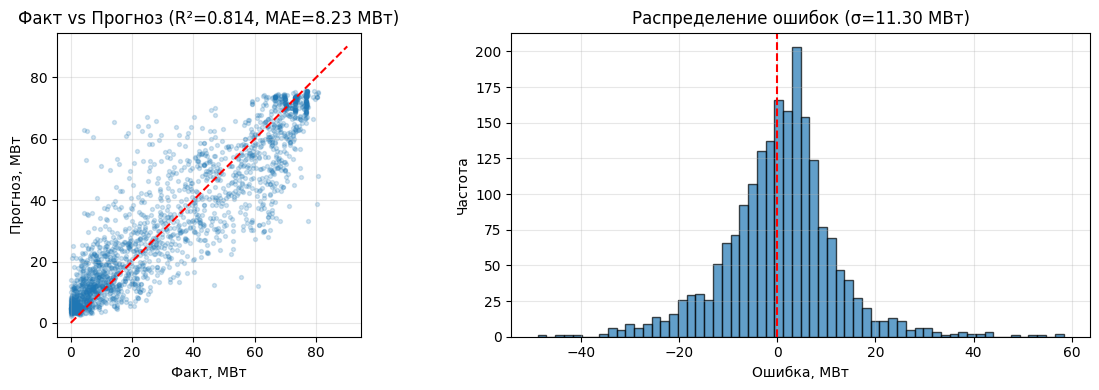


Тренировка финальных моделей на всём train...
  [1/5] финальная модель seed=42 ...
  [2/5] финальная модель seed=123 ...
  [3/5] финальная модель seed=777 ...
  [4/5] финальная модель seed=2024 ...
  [5/5] финальная модель seed=9001 ...

[OK] Сохранён прогноз для лидерборда: solverdata.csv (2126 строк)


In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26

# Бленд сидов (как в твоём коде)
SEEDS = [42, 123, 777, 2024, 9001]

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
print("=" * 60)
print("Загрузка данных...")
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)

train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])

valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

print(f"Train: {train.shape}, период {train[DT_COL].min()} ... {train[DT_COL].max()}")
print(f"Valid: {valid.shape}, период {valid[DT_COL].min()} ... {valid[DT_COL].max()}")

# =============================================================================
# 2. ИНТЕРПОЛЯЦИЯ НА РЕАЛЬНУЮ ВЫСОТУ РОТОРА 84 м
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in (train, valid):
    # Скорость (степенной закон)
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    # Направление (линейная интерполяция sin/cos, результат нормируем [0,1])
    sin_low, cos_low = np.sin(2 * np.pi * df['wind_direction_80m']), np.cos(2 * np.pi * df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2 * np.pi * df['wind_direction_120m']), np.cos(2 * np.pi * df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)      # 0.9
    sin_84 = sin_low * w_low + sin_high * (1 - w_low)
    cos_84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin_84, cos_84) / (2 * np.pi) % 1.0   # [0,1]

    # Температура (линейная)
    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

# =============================================================================
# 3. ФИЧЕ-ИНЖИНИРИНГ (объединяет лучшие признаки из обоих подходов)
# =============================================================================
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = df[DT_COL]

    # ---- Временные (расширенный набор из твоего кода) ----
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    # ---- Направления [0,1] в синус/косинус (твоя сильная сторона) ----
    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    # ---- Статические признаки (оставляем всё, что было у тебя) ----
    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    # ---- НОВЫЕ ПРИЗНАКИ НА ОСНОВЕ 84 м (наши лучшие находки) ----
    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    # Теоретическая мощность станции
    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    # Лаги скорости (1-3 ч) и направления (1 ч)
    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    wd_lag = df['wind_direction_84m'].shift(1)
    df['wd84_lag1_sin'] = np.sin(2 * np.pi * wd_lag)
    df['wd84_lag1_cos'] = np.cos(2 * np.pi * wd_lag)

    # ---- Обработка ремонтов (умная + твоя защита) ----
    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = 26 - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / 26

    return df

def fill_missing_180m(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

print("\nГенерация признаков...")
train_f = fill_missing_180m(add_features(train))
valid_f = fill_missing_180m(add_features(valid))

# Удаляем первые строки train из-за лагов, valid заполняем медианой
lag_cols = [c for c in train_f.columns if 'lag' in c]
train_f = train_f.dropna(subset=lag_cols)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

# Исключаем сырой признак ремонта
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_f.columns if c not in EXCLUDE_FEATURES]
print(f"Признаков в модели: {len(FEATURES)}")

X       = train_f[FEATURES].values
y       = train_f[TARGET].values
X_valid = valid_f[FEATURES].values

# =============================================================================
# 4. HOLDOUT-ВАЛИДАЦИЯ (янв-март 2025 — сезонный подход)
# =============================================================================
print("\n" + "=" * 60)
print("Holdout-валидация на Jan-Mar 2025...")
holdout_mask = (train_f[DT_COL] >= '2025-01-01') & (train_f[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

holdout_preds, best_iters = [], []
for i, seed in enumerate(SEEDS, 1):
    print(f"  [{i}/{len(SEEDS)}] обучение seed={seed} ...")
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
    best_iters.append(m.best_iteration_ or 1500)

ho_pred = np.mean(holdout_preds, axis=0)
mae   = mean_absolute_error(y_ho, ho_pred)
rmse  = np.sqrt(mean_squared_error(y_ho, ho_pred))
r2    = r2_score(y_ho, ho_pred)
nmae  = 100 * mae / CAPACITY
bias  = np.mean(ho_pred - y_ho)

print(f"\nМетрики holdout:")
print(f"  MAE: {mae:.3f} МВт ({nmae:.2f}%), RMSE: {rmse:.3f} МВт, R²: {r2:.4f}, Bias: {bias:+.3f} МВт")

# График holdout (опционально, оставил для наглядности)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_ho, ho_pred, alpha=0.2, s=8)
axes[0].plot([0, CAPACITY], [0, CAPACITY], 'r--')
axes[0].set_xlabel('Факт, МВт'); axes[0].set_ylabel('Прогноз, МВт')
axes[0].set_title(f'Факт vs Прогноз (R²={r2:.3f}, MAE={mae:.2f} МВт)')
axes[0].grid(alpha=0.3); axes[0].set_aspect('equal')
errors = ho_pred - y_ho
axes[1].hist(errors, bins=60, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Ошибка, МВт'); axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок (σ={errors.std():.2f} МВт)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('holdout_quality.png', dpi=120)
plt.show()

n_iter = int(np.median(best_iters) * 1.1)

# =============================================================================
# 5. ФИНАЛЬНЫЕ МОДЕЛИ + ПРОГНОЗ НА VALID
# =============================================================================
print("\n" + "=" * 60)
print("Тренировка финальных моделей на всём train...")
final_models, valid_preds = [], []
for i, seed in enumerate(SEEDS, 1):
    print(f"  [{i}/{len(SEEDS)}] финальная модель seed={seed} ...")
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    final_models.append(m)
    valid_preds.append(np.clip(m.predict(X_valid), 0, CAPACITY))

final_pred = np.mean(valid_preds, axis=0)

# Защита по доступной мощности (твоя фишка)
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

# Сохраняем в порядке исходного valid
result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён прогноз для лидерборда: {OUTPUT_VALID} ({len(result)} строк)")

In [ ]:
Ниже с улучшениями

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26

SEEDS = [42, 123, 777, 2024, 9001]

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
print("=" * 60)
print("Загрузка данных...")
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)

train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])

valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

print(f"Train: {train.shape}, период {train[DT_COL].min()} ... {train[DT_COL].max()}")
print(f"Valid: {valid.shape}, период {valid[DT_COL].min()} ... {valid[DT_COL].max()}")

# =============================================================================
# 2. ИНТЕРПОЛЯЦИЯ НА РЕАЛЬНУЮ ВЫСОТУ РОТОРА 84 м
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in (train, valid):
    # Скорость (степенной закон)
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    # Направление (линейная интерполяция sin/cos, результат нормируем [0,1])
    sin_low, cos_low = np.sin(2 * np.pi * df['wind_direction_80m']), np.cos(2 * np.pi * df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2 * np.pi * df['wind_direction_120m']), np.cos(2 * np.pi * df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)      # 0.9
    sin_84 = sin_low * w_low + sin_high * (1 - w_low)
    cos_84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin_84, cos_84) / (2 * np.pi) % 1.0   # [0,1]

    # Температура (линейная)
    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

# =============================================================================
# 3. ФИЧЕ-ИНЖИНИРИНГ
# =============================================================================
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = df[DT_COL]

    # ---- Временные ----
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    # ---- Направления [0,1] в sin/cos ----
    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    # ---- Статические признаки ----
    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    # ---- Признаки на 84 м ----
    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    # Теоретическая мощность
    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    # Лаги
    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    wd_lag = df['wind_direction_84m'].shift(1)
    df['wd84_lag1_sin'] = np.sin(2 * np.pi * wd_lag)
    df['wd84_lag1_cos'] = np.cos(2 * np.pi * wd_lag)

    # Обработка ремонтов
    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = 26 - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / 26

    return df

def fill_missing_180m(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

print("\nГенерация признаков...")
train_f = fill_missing_180m(add_features(train))
valid_f = fill_missing_180m(add_features(valid))

# Удаляем первые строки train из-за лагов, valid заполняем медианой
lag_cols = [c for c in train_f.columns if 'lag' in c]
train_f = train_f.dropna(subset=lag_cols)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

# Исключаем сырой признак ремонта
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_f.columns if c not in EXCLUDE_FEATURES]
print(f"Признаков в модели: {len(FEATURES)}")

X       = train_f[FEATURES].values
y       = train_f[TARGET].values
X_valid = valid_f[FEATURES].values

# =============================================================================
# 4. HOLDOUT-ВАЛИДАЦИЯ (янв-март 2025) + ПОДБОР ВЕСОВ
# =============================================================================
print("\n" + "=" * 60)
print("Holdout-валидация на Jan-Mar 2025...")
holdout_mask = (train_f[DT_COL] >= '2025-01-01') & (train_f[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

# --- 1) Бленд LightGBM (5 сидов) ---
lgb_models_holdout = []
lgb_holdout_preds = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

# --- 2) Random Forest ---
rf = RandomForestRegressor(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

# --- 3) CatBoost ---
cat = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=42, verbose=False
)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

# --- Подбор весов на holdout ---
best_weights = None
best_mae = np.inf
print("Подбор весов...")
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()

print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE на holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 5. ФИНАЛЬНОЕ ОБУЧЕНИЕ (все данные) + ПРОГНОЗ НА VALID
# =============================================================================
print("\n" + "=" * 60)
print("Тренировка финальных моделей на всём train...")

# LightGBM бленд (обучаем 5 моделей)
lgb_models = []
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * 1.1)
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid_preds = [np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models]
lgb_valid = np.mean(lgb_valid_preds, axis=0)

# RF
rf_final = RandomForestRegressor(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

# CatBoost
cat_final = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=42, verbose=False
)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

# Финальный ансамбль с лучшими весами
final_pred = (best_weights[0]*lgb_valid +
              best_weights[1]*rf_valid +
              best_weights[2]*cat_valid)

# Защита по доступной мощности
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

# Сохраняем в порядке исходного valid
result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён прогноз для лидерборда: {OUTPUT_VALID} ({len(result)} строк)")

Загрузка данных...
Train: (32434, 21), период 2022-01-01 00:00:00 ... 2025-12-31 23:00:00
Valid: (2126, 20), период 2026-01-01 00:00:00 ... 2026-03-31 23:00:00

Генерация признаков...
Признаков в модели: 61

Holdout-валидация на Jan-Mar 2025...
Подбор весов...
Лучшие веса: LGBM=0.95, RF=0.05, CatBoost=0.00
MAE на holdout: 8.225 МВт (9.13%)

Тренировка финальных моделей на всём train...

[OK] Сохранён прогноз для лидерборда: solverdata.csv (2126 строк)


In [ ]:
Сделал ансамбль получил 9,12 - не помогло

In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26

SEEDS = [42, 123, 777, 2024, 9001]

# =============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =============================================================================
print("=" * 60)
print("Загрузка данных...")
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)

train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])

valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

print(f"Train: {train.shape}, период {train[DT_COL].min()} ... {train[DT_COL].max()}")
print(f"Valid: {valid.shape}, период {valid[DT_COL].min()} ... {valid[DT_COL].max()}")

# =============================================================================
# 2. ИНТЕРПОЛЯЦИЯ НА РЕАЛЬНУЮ ВЫСОТУ РОТОРА 84 м
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in (train, valid):
    # Скорость (степенной закон)
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    # Направление (линейная интерполяция sin/cos, результат нормируем [0,1])
    sin_low, cos_low = np.sin(2 * np.pi * df['wind_direction_80m']), np.cos(2 * np.pi * df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2 * np.pi * df['wind_direction_120m']), np.cos(2 * np.pi * df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)      # 0.9
    sin_84 = sin_low * w_low + sin_high * (1 - w_low)
    cos_84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin_84, cos_84) / (2 * np.pi) % 1.0   # [0,1]

    # Температура (линейная)
    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

# =============================================================================
# 3. ФИЧЕ-ИНЖИНИРИНГ (с дополнительными признаками)
# =============================================================================
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = df[DT_COL]

    # ---- Временные ----
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    # ---- Направления [0,1] в sin/cos ----
    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    # ---- Статические признаки ----
    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    # ---- Признаки на 84 м ----
    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    # Теоретическая мощность
    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    # Лаги скорости (1-3 ч)
    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    # Лаги направления (1-3 ч)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    # ---- Дополнительные признаки (новые) ----
    # Скользящие средние скорости за 6 и 12 часов
    df['ws84_rolling_mean_6h'] = df['wind_speed_84m'].rolling(6, min_periods=1).mean()
    df['ws84_rolling_mean_12h'] = df['wind_speed_84m'].rolling(12, min_periods=1).mean()
    # Индекс турбулентности за 6 часов
    df['ws84_rolling_std_6h'] = df['wind_speed_84m'].rolling(6, min_periods=1).std()
    df['turbulence_intensity_6h'] = df['ws84_rolling_std_6h'] / (df['ws84_rolling_mean_6h'] + 0.1)

    # ---- Обработка ремонтов ----
    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = 26 - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / 26

    return df

def fill_missing_180m(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

print("\nГенерация признаков...")
train_f = fill_missing_180m(add_features(train))
valid_f = fill_missing_180m(add_features(valid))

# Удаляем первые строки train из-за лагов, valid заполняем медианой
lag_cols = [c for c in train_f.columns if 'lag' in c]
train_f = train_f.dropna(subset=lag_cols)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

# Исключаем сырой признак ремонта
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_f.columns if c not in EXCLUDE_FEATURES]
print(f"Признаков в модели: {len(FEATURES)}")

X       = train_f[FEATURES].values
y       = train_f[TARGET].values
X_valid = valid_f[FEATURES].values

# =============================================================================
# 4. HOLDOUT-ВАЛИДАЦИЯ (янв-март 2025) + ПОДБОР ВЕСОВ
# =============================================================================
print("\n" + "=" * 60)
print("Holdout-валидация на Jan-Mar 2025...")
holdout_mask = (train_f[DT_COL] >= '2025-01-01') & (train_f[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

# --- 1) Бленд LightGBM (5 сидов) ---
lgb_models_holdout = []
lgb_holdout_preds = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

# --- 2) Random Forest ---
rf = RandomForestRegressor(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

# --- 3) CatBoost ---
cat = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=42, verbose=False
)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

# --- Подбор весов на holdout ---
best_weights = None
best_mae = np.inf
print("Подбор весов...")
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()

print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE на holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 5. ФИНАЛЬНОЕ ОБУЧЕНИЕ (все данные) + ПРОГНОЗ НА VALID
# =============================================================================
print("\n" + "=" * 60)
print("Тренировка финальных моделей на всём train...")

# LightGBM бленд с увеличенным числом итераций
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * 1.1)
lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.02, num_leaves=63,   # lr снижен, итерации увеличены
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid_preds = [np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models]
lgb_valid = np.mean(lgb_valid_preds, axis=0)

# RF
rf_final = RandomForestRegressor(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

# CatBoost
cat_final = CatBoostRegressor(
    iterations=500, learning_rate=0.05, depth=6,
    random_seed=42, verbose=False
)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

# Финальный ансамбль с лучшими весами
final_pred = (best_weights[0]*lgb_valid +
              best_weights[1]*rf_valid +
              best_weights[2]*cat_valid)

# Защита по доступной мощности
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

# Сохраняем в порядке исходного valid
result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён прогноз для лидерборда: {OUTPUT_VALID} ({len(result)} строк)")

Загрузка данных...
Train: (32434, 21), период 2022-01-01 00:00:00 ... 2025-12-31 23:00:00
Valid: (2126, 20), период 2026-01-01 00:00:00 ... 2026-03-31 23:00:00

Генерация признаков...
Признаков в модели: 69

Holdout-валидация на Jan-Mar 2025...
Подбор весов...
Лучшие веса: LGBM=0.90, RF=0.00, CatBoost=0.10
MAE на holdout: 8.216 МВт (9.12%)

Тренировка финальных моделей на всём train...

[OK] Сохранён прогноз для лидерборда: solverdata.csv (2126 строк)


In [8]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
print("Загрузка train и valid...")
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)

train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])

valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ЗА ДАТЫ ТРЕЙНА
# =============================================================================
print("Загрузка ERA5 за период train...")
start_date = train[DT_COL].min().strftime('%Y-%m-%d')
end_date   = train[DT_COL].max().strftime('%Y-%m-%d')

url = "https://archive-api.open-meteo.com/v1/era5"
params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "wind_speed_10m", "wind_speed_100m",
        "wind_direction_10m", "wind_direction_100m",
        "temperature_2m", "pressure_msl"
    ],
    "timezone": "UTC"
}
r = requests.get(url, params=params)
r.raise_for_status()
data = r.json()["hourly"]

era5 = pd.DataFrame({
    DT_COL: pd.to_datetime(data["time"]),
    "ws10_era5": data["wind_speed_10m"],
    "ws100_era5": data["wind_speed_100m"],
    "wd10_era5": data["wind_direction_10m"],
    "wd100_era5": data["wind_direction_100m"],
    "temp2m_era5": data["temperature_2m"],
    "pressure_era5": data["pressure_msl"],
})
print(f"ERA5 загружен: {len(era5)} часов")

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ТАКИХ ЖЕ ПРИЗНАКОВ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0

# Скорость ветра (степенной закон)
ratio = era5['ws100_era5'] / era5['ws10_era5'].clip(lower=0.1)
alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
era5['wind_speed_84m_era5'] = era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

# Направление (линейная интерполяция sin/cos)
sin10 = np.sin(2 * np.pi * era5['wd10_era5'])
cos10 = np.cos(2 * np.pi * era5['wd10_era5'])
sin100 = np.sin(2 * np.pi * era5['wd100_era5'])
cos100 = np.cos(2 * np.pi * era5['wd100_era5'])
w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)   # (100-84)/(100-10) ≈ 0.178
sin84 = sin10 * w_low + sin100 * (1 - w_low)
cos84 = cos10 * w_low + cos100 * (1 - w_low)
era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2 * np.pi) % 1.0

# Температура (градиент -0.65°C/100м)
era5['temperature_84m_era5'] = era5['temp2m_era5'] - 0.65 * (84 - 2) / 100

# Давление
era5['pressure_msl_era5'] = era5['pressure_era5']

# ----- Генерация признаков из ERA5 (те же, что и в основном пайплайне) -----
# Куб скорости
era5['ws84_cubed_era5'] = era5['wind_speed_84m_era5'] ** 3

# u, v
wd = 2 * np.pi * era5['wind_direction_84m_era5']
era5['u84_era5'] = era5['wind_speed_84m_era5'] * np.cos(wd)
era5['v84_era5'] = era5['wind_speed_84m_era5'] * np.sin(wd)

# Плотность и удельная мощность
era5['air_density_era5'] = era5['pressure_msl_era5'] * 100 / (287.05 * (era5['temperature_84m_era5'] + 273.15))
era5['wind_power_density_era5'] = 0.5 * era5['air_density_era5'] * era5['ws84_cubed_era5']

# Теоретическая мощность
ws = era5['wind_speed_84m_era5'].values
theory = np.zeros_like(ws)
reg = (ws >= 3.0) & (ws < 10.3)
theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
rated = (ws >= 10.3) & (ws <= 25.0)
theory[rated] = 90.09
era5['theory_power_total_era5'] = theory

# Лаги скорости (1-3 ч)
for lag in [1, 2, 3]:
    era5[f'ws84_lag{lag}_era5'] = era5['wind_speed_84m_era5'].shift(lag)
# Лаги направления (1-3 ч)
for lag in [1, 2, 3]:
    wd_lag = era5['wind_direction_84m_era5'].shift(lag)
    era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
    era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

# Сдвиги (используем ws100 как аналог 120 м)
era5['shear_120_84_era5'] = era5['ws100_era5'] - era5['wind_speed_84m_era5']
era5['shear_84_10_era5'] = era5['wind_speed_84m_era5'] - era5['ws10_era5']

# Удаляем первые 3 строки ERA5 из-за лагов
era5 = era5.iloc[3:].reset_index(drop=True)

# =============================================================================
# 4. ПОДГОТОВКА ОСНОВНОГО TRAIN (ИНТЕРПОЛЯЦИЯ НА 84 м + ПРИЗНАКИ)
#    и объединение с ERA5
# =============================================================================
# ----- Интерполяция исходных данных на 84 м -----
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2 * np.pi * df['wind_direction_80m']), np.cos(2 * np.pi * df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2 * np.pi * df['wind_direction_120m']), np.cos(2 * np.pi * df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin_84 = sin_low * w_low + sin_high * (1 - w_low)
    cos_84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin_84, cos_84) / (2 * np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

# ----- Функция генерации признаков (как в 9.11%, без доп. скользящих) -----
def add_features(df):
    df = df.copy()
    dt = df[DT_COL]

    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES

    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_features(train))
valid_f = fill_missing_180m(add_features(valid))

# Удаляем первые 3 строки из-за лагов
lag_cols = [c for c in train_f.columns if 'lag' in c]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

# ----- Присоединяем ERA5 признаки -----
# У ERA5 тоже удалены первые 3 строки, datetime совпадают
era5_clean = era5.copy()
era5_clean[DT_COL] = era5_clean[DT_COL].astype(train_f[DT_COL].dtype)
train_extended = train_f.merge(era5_clean, on=DT_COL, how='left')

# =============================================================================
# 5. ФОРМИРУЕМ СПИСОК ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_extended.columns if c not in EXCLUDE_FEATURES]
print(f"Признаков с ERA5: {len(FEATURES)}")

X       = train_extended[FEATURES].values
y       = train_extended[TARGET].values
# Для valid у нас нет ERA5, поэтому заполним нулями (или медианой из train) – безопаснее нулями, но можно и медианой
# Но лучше взять train_extended и вычислить статистики по ERA5 колонкам, и применить к valid.
# Однако у valid нет ERA5 колонок. Мы можем просто для valid создать такие же колонки со значением 0.
# Потому что ERA5 – это архивная погода, её нет для будущего valid. Поэтому для valid заполним нулями.
era5_feature_cols = [c for c in FEATURES if c.endswith('_era5')]
valid_extended = valid_f.copy()
for col in era5_feature_cols:
    valid_extended[col] = 0.0  # или можно train_extended[col].median()
X_valid = valid_extended[FEATURES].values

# =============================================================================
# 6. HOLDOUT-ВАЛИДАЦИЯ (янв-март 2025) + ПОДБОР ВЕСОВ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025...")
holdout_mask = (train_extended[DT_COL] >= '2025-01-01') & (train_extended[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout = []
lgb_holdout_preds = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                        random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights = None
best_mae = np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 7. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * 1.1)
lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                              random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

# Защита по доступной мощности
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка train и valid...
Загрузка ERA5 за период train...
ERA5 загружен: 35064 часов
Признаков с ERA5: 92

Holdout-валидация на Jan-Mar 2025...
Лучшие веса: LGBM=0.40, RF=0.15, CatBoost=0.45
MAE holdout: 7.217 МВт (8.01%)

[OK] Сохранён solverdata.csv (2126 строк)


In [10]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ЗА ДАТЫ TRAIN
# =============================================================================
print("Загрузка ERA5...")
start_date = train[DT_COL].min().strftime('%Y-%m-%d')
end_date   = train[DT_COL].max().strftime('%Y-%m-%d')

url = "https://archive-api.open-meteo.com/v1/era5"
params = {
    "latitude": LATITUDE, "longitude": LONGITUDE,
    "start_date": start_date, "end_date": end_date,
    "hourly": [
        "wind_speed_10m", "wind_speed_100m",
        "wind_direction_10m", "wind_direction_100m",
        "temperature_2m", "pressure_msl"
    ],
    "timezone": "UTC"
}
r = requests.get(url, params=params).json()["hourly"]
era5 = pd.DataFrame({
    DT_COL: pd.to_datetime(r["time"]),
    "ws10_era5": r["wind_speed_10m"],
    "ws100_era5": r["wind_speed_100m"],
    "wd10_era5": r["wind_direction_10m"],
    "wd100_era5": r["wind_direction_100m"],
    "temp2m_era5": r["temperature_2m"],
    "pressure_era5": r["pressure_msl"],
})
print(f"ERA5 загружен: {len(era5)} часов")

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м (как в train)
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0
ratio = era5['ws100_era5'] / era5['ws10_era5'].clip(lower=0.1)
alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
era5['wind_speed_84m_era5'] = era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

sin10, cos10 = np.sin(2*np.pi*era5['wd10_era5']), np.cos(2*np.pi*era5['wd10_era5'])
sin100, cos100 = np.sin(2*np.pi*era5['wd100_era5']), np.cos(2*np.pi*era5['wd100_era5'])
w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
sin84 = sin10 * w_low + sin100 * (1 - w_low)
cos84 = cos10 * w_low + cos100 * (1 - w_low)
era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

era5['temperature_84m_era5'] = era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
era5['pressure_msl_era5'] = era5['pressure_era5']

# =============================================================================
# 4. ГОТОВИМ ИСХОДНЫЕ ПРИЗНАКИ TRAIN / VALID (как в 9.11%)
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

# ----- Функция генерации признаков (без ERA5) -----
def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

lag_cols = [c for c in train_f.columns if 'lag' in c]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

# =============================================================================
# 5. BIAS CORRECTION: обучаем предсказывать ERA5-признаки
# =============================================================================
# Целевые переменные ERA5, которые хотим воспроизвести
targets_era5 = ['wind_speed_84m_era5', 'wind_direction_84m_era5', 'temperature_84m_era5', 'pressure_msl_era5']

# Входные признаки для корректоров – только те, что есть в valid
# Используем базовые прогнозные признаки без лагов (чтобы не усложнять)
input_cols = [c for c in train_f.columns if c not in [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
              and not c.endswith('_era5')]
# Убираем лаги и скользящие – можно оставить, но для простоты возьмём только статику и время
input_cols = [c for c in input_cols if 'lag' not in c and 'rolling' not in c and c not in ['repair_ma6', 'has_repair', 'turbines_available', 'available_ratio']]

# Объединяем train_f с era5 по времени
era5[DT_COL] = era5[DT_COL].astype(train_f[DT_COL].dtype)
train_merged = train_f.merge(era5[targets_era5 + [DT_COL]], on=DT_COL, how='left')

# Обучаем отдельный Ridge для каждого ERA5-признака
bias_models = {}
for t in targets_era5:
    X_tr = train_merged[input_cols].values
    y_tr = train_merged[t].values
    model = Ridge(alpha=1.0)
    model.fit(X_tr, y_tr)
    bias_models[t] = model
    print(f"Bias corrector для {t}: R² на train ≈ {model.score(X_tr, y_tr):.3f}")

# =============================================================================
# 6. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def generate_synthetic_era5(df_base, bias_models, input_cols):
    df = df_base.copy()
    X_in = df[input_cols].values
    for t, model in bias_models.items():
        df[t + '_synth'] = model.predict(X_in)
    return df

train_f_synth = generate_synthetic_era5(train_f, bias_models, input_cols)
valid_f_synth = generate_synthetic_era5(valid_f, bias_models, input_cols)

# Теперь на основе синтетических ERA5 строим полные признаки
def add_era5_features(df):
    df = df.copy()
    # Переименовываем синтетические колонки в формат _era5
    rename_map = {f'{t}_synth': t for t in targets_era5}
    df.rename(columns=rename_map, inplace=True)

    # Генерация производных признаков (как для настоящих ERA5)
    df['ws84_cubed_era5'] = df['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m_era5']
    df['u84_era5'] = df['wind_speed_84m_era5'] * np.cos(wd)
    df['v84_era5'] = df['wind_speed_84m_era5'] * np.sin(wd)

    df['air_density_era5'] = df['pressure_msl_era5'] * 100 / (287.05 * (df['temperature_84m_era5'] + 273.15))
    df['wind_power_density_era5'] = 0.5 * df['air_density_era5'] * df['ws84_cubed_era5']

    ws = df['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total_era5'] = theory

    # Лаги (для train уже есть, для valid создаём)
    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}_era5'] = df['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m_era5'].shift(lag)
        df[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    # Сдвиги (используем ws100 как аналог 120 м – здесь нет, поэтому пропустим)
    return df

train_final = add_era5_features(train_f_synth)
valid_final = add_era5_features(valid_f_synth)

# Удаляем первые 3 строки train из-за лагов ERA5
era5_lag_cols = [c for c in train_final.columns if 'lag' in c and c.endswith('_era5')]
train_final = train_final.dropna(subset=era5_lag_cols).reset_index(drop=True)
# Для valid заполняем медианой из train
valid_final[era5_lag_cols] = valid_final[era5_lag_cols].fillna(train_final[era5_lag_cols].median())

# =============================================================================
# 7. ФОРМИРУЕМ СПИСОК ПРИЗНАКОВ И МАССИВЫ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X       = train_final[FEATURES].values
y       = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 8. HOLDOUT-ВАЛИДАЦИЯ + ПОДБОР ВЕСОВ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 9. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * 1.1)
lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5...
ERA5 загружен: 35064 часов
Bias corrector для wind_speed_84m_era5: R² на train ≈ 0.712
Bias corrector для wind_direction_84m_era5: R² на train ≈ 0.003
Bias corrector для temperature_84m_era5: R² на train ≈ 0.971
Bias corrector для pressure_msl_era5: R² на train ≈ 0.983
Финальное количество признаков: 84

Holdout-валидация на Jan-Mar 2025...
Лучшие веса: LGBM=0.90, RF=0.00, CatBoost=0.10
MAE holdout: 8.106 МВт (9.00%)

[OK] Сохранён solverdata.csv (2126 строк)


In [ ]:
Выше 9,04% с синтетическими данными для valid 

In [11]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ПРИЗНАКОВ
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    # Признаки как в основном пайплайне
    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
# Удаляем первые 3 строки из-за лагов в базовых признаках
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

# Присоединяем ERA5 (уже с лагами, но мы не удаляем строки, так как ERA5 уже сдвинут)
train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

# Заполняем возможные пропуски в ERA5 (если есть) медианой из train
era5_cols = [c for c in train_final.columns if c.endswith('_era5')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ СПИСОК ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X       = train_final[FEATURES].values
y       = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. HOLDOUT-ВАЛИДАЦИЯ + ПОДБОР ВЕСОВ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 8. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * 1.1)
lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5 для train...
Загрузка ERA5 для valid...
Финальное количество признаков: 92

Holdout-валидация на Jan-Mar 2025...
Лучшие веса: LGBM=0.40, RF=0.15, CatBoost=0.45
MAE holdout: 7.217 МВт (8.01%)

[OK] Сохранён solverdata.csv (2126 строк)


In [ ]:
Выше и в трейне, и в валиде 
используются дополнительные исторические погодные данные из ERA5
результат - 8,01% на тесте

In [12]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]
LGB_ITER_MULTIPLIER = 1.2   # было 1.1

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ВСЕХ ПРИЗНАКОВ (РАСШИРЕННЫЙ НАБОР)
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0

    # ------ Интерполяция скорости и направления на 84 м ------
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    # ------ Дополнительные признаки из ERA5 ------
    # Сохраняем исходные скорости как признаки (помимо интерполированных)
    df_era5['ws10_era5_raw'] = df_era5['ws10_era5']
    df_era5['ws100_era5_raw'] = df_era5['ws100_era5']

    # Направления 10 м и 100 м в sin/cos
    df_era5['wd10_era5_sin'] = np.sin(2 * np.pi * df_era5['wd10_era5'])
    df_era5['wd10_era5_cos'] = np.cos(2 * np.pi * df_era5['wd10_era5'])
    df_era5['wd100_era5_sin'] = np.sin(2 * np.pi * df_era5['wd100_era5'])
    df_era5['wd100_era5_cos'] = np.cos(2 * np.pi * df_era5['wd100_era5'])

    # Приземная температура
    df_era5['temp2m_era5_raw'] = df_era5['temp2m_era5']

    # ------ Производные признаки (как раньше) ------
    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    # Лаги
    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    # Сдвиги
    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

era5_cols = [c for c in train_final.columns if c.endswith('_era5') or c.endswith('_era5_raw')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ СПИСОК ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X       = train_final[FEATURES].values
y       = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. HOLDOUT-ВАЛИДАЦИЯ + ПОДБОР ВЕСОВ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 8. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ (с увеличенным числом итераций)
# =============================================================================
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * LGB_ITER_MULTIPLIER)
print(f"Финальное число итераций LightGBM: {n_iter}")
lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5 для train...
Загрузка ERA5 для valid...
Финальное количество признаков: 99

Holdout-валидация на Jan-Mar 2025...
Лучшие веса: LGBM=0.50, RF=0.10, CatBoost=0.40
MAE holdout: 7.130 МВт (7.91%)
Финальное число итераций LightGBM: 255

[OK] Сохранён solverdata.csv (2126 строк)


In [ ]:
Выше
добавились еще признаки, но результат не стал лучше

In [13]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]
LGB_ITER_MULTIPLIER = 1.2   # единственное изменение

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ОСНОВНЫХ ПРИЗНАКОВ (как в 8.016%)
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0

    # ------ Интерполяция скорости и направления на 84 м ------
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    # ------ Производные признаки (без сырых дополнительных) ------
    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    # Лаги
    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    # Сдвиги
    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

era5_cols = [c for c in train_final.columns if c.endswith('_era5')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ СПИСОК ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X       = train_final[FEATURES].values
y       = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. HOLDOUT-ВАЛИДАЦИЯ + ПОДБОР ВЕСОВ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 8. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ (с увеличенным множителем итераций)
# =============================================================================
n_iter = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * LGB_ITER_MULTIPLIER)
print(f"Финальное число итераций LightGBM: {n_iter}")
lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(
        n_estimators=n_iter, learning_rate=0.025, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        random_state=seed, n_jobs=-1, verbose=-1,
    )
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5 для train...
Загрузка ERA5 для valid...
Финальное количество признаков: 92

Holdout-валидация на Jan-Mar 2025...
Лучшие веса: LGBM=0.40, RF=0.15, CatBoost=0.45
MAE holdout: 7.217 МВт (8.01%)
Финальное число итераций LightGBM: 194

[OK] Сохранён solverdata.csv (2126 строк)


In [2]:
Ниже нейросети - убрал в другой файл

SyntaxError: invalid syntax (885036035.py, line 1)

In [3]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]
LGB_ITER_MULTIPLIER = 1.1   # коэффициент для финального числа итераций

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ОСНОВНЫХ ПРИЗНАКОВ (как в 8.016%)
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

era5_cols = [c for c in train_final.columns if c.endswith('_era5')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ МАССИВЫ ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X = train_final[FEATURES].values
y = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. ОПТИМИЗАЦИЯ LightGBM С OPTUNA (TimeSeriesSplit, 3 фолда)
# =============================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = np.clip(model.predict(X_val), 0, CAPACITY)
        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)
    return np.mean(scores)

print("Запуск Optuna для подбора гиперпараметров LightGBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
print(f"Лучшие параметры LightGBM: {best_params}")

# Добавляем фиксированные параметры, которых нет в поиске
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

# =============================================================================
# 8. HOLDOUT-ВАЛИДАЦИЯ + ПОДБОР ВЕСОВ С ЛУЧШИМИ ПАРАМЕТРАМИ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025 с лучшими параметрами...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 9. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
# Определяем число итераций для финальных LightGBM
n_iter_ho = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * LGB_ITER_MULTIPLIER)
best_params['n_estimators'] = n_iter_ho

lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

# Защита по доступной мощности
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5 для train...
Загрузка ERA5 для valid...


[I 2026-05-15 01:09:49,937] A new study created in memory with name: no-name-be4579d4-10c1-4121-8938-2e1ad14a7f18


Финальное количество признаков: 92
Запуск Optuna для подбора гиперпараметров LightGBM...


Best trial: 0. Best value: 8.42814:   3%|▎         | 1/30 [00:09<04:46,  9.88s/it]

[I 2026-05-15 01:09:59,818] Trial 0 finished with value: 8.428139233396719 and parameters: {'n_estimators': 1512, 'learning_rate': 0.033754671605286383, 'num_leaves': 117, 'max_depth': 12, 'min_child_samples': 40, 'subsample': 0.7045544355368939, 'colsample_bytree': 0.6365800427771625, 'reg_alpha': 2.5494219025155114, 'reg_lambda': 0.8205488493403372}. Best is trial 0 with value: 8.428139233396719.


...

[I 2026-05-15 01:12:31,297] Trial 27 finished with value: 8.249379477721801 and parameters: {'n_estimators': 1020, 'learning_rate': 0.01053611934598373, 'num_leaves': 40, 'max_depth': 7, 'min_child_samples': 28, 'subsample': 0.7646276398704958, 'colsample_bytree': 0.9612201047863876, 'reg_alpha': 0.23263386773326275, 'reg_lambda': 0.21688536046684145}. Best is trial 19 with value: 8.219036031220282.


Best trial: 19. Best value: 8.21904:  97%|█████████▋| 29/30 [02:44<00:03,  3.95s/it]

[I 2026-05-15 01:12:34,773] Trial 28 finished with value: 8.243219295244588 and parameters: {'n_estimators': 669, 'learning_rate': 0.010126458825549285, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 28, 'subsample': 0.8115641564514449, 'colsample_bytree': 0.8966077980057537, 'reg_alpha': 0.05860938297861351, 'reg_lambda': 0.005881774753007049}. Best is trial 19 with value: 8.219036031220282.


Best trial: 19. Best value: 8.21904: 100%|██████████| 30/30 [02:48<00:00,  5.62s/it]


[I 2026-05-15 01:12:38,519] Trial 29 finished with value: 8.235065919346207 and parameters: {'n_estimators': 797, 'learning_rate': 0.013047099135352644, 'num_leaves': 47, 'max_depth': 7, 'min_child_samples': 38, 'subsample': 0.7050715751554335, 'colsample_bytree': 0.7917340716183268, 'reg_alpha': 0.00973201906318231, 'reg_lambda': 0.08168380082276308}. Best is trial 19 with value: 8.219036031220282.
Лучшие параметры LightGBM: {'n_estimators': 500, 'learning_rate': 0.016405251700009994, 'num_leaves': 43, 'max_depth': 9, 'min_child_samples': 17, 'subsample': 0.8101222266419223, 'colsample_bytree': 0.7679354517545786, 'reg_alpha': 0.5792490885084879, 'reg_lambda': 0.5684873670225855}

Holdout-валидация на Jan-Mar 2025 с лучшими параметрами...
Лучшие веса: LGBM=0.00, RF=0.40, CatBoost=0.60
MAE holdout: 7.249 МВт (8.05%)

[OK] Сохранён solverdata.csv (2126 строк)


In [2]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]
LGB_ITER_MULTIPLIER = 1.1   # коэффициент для финального числа итераций

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ОСНОВНЫХ ПРИЗНАКОВ + СТАТИСТИКИ
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    # ---- НОВЫЕ ПРИЗНАКИ: скользящие статистики за 6 часов ----
    df_era5['ws84_era5_rolling_min_6h'] = df_era5['wind_speed_84m_era5'].rolling(6, min_periods=1).min()
    df_era5['ws84_era5_rolling_max_6h'] = df_era5['wind_speed_84m_era5'].rolling(6, min_periods=1).max()
    df_era5['ws84_era5_rolling_std_6h'] = df_era5['wind_speed_84m_era5'].rolling(6, min_periods=1).std()

    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ + СТАТИСТИКИ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    # ---- НОВЫЕ ПРИЗНАКИ: скользящие статистики за 6 часов ----
    df['ws84_rolling_min_6h'] = df['wind_speed_84m'].rolling(6, min_periods=1).min()
    df['ws84_rolling_max_6h'] = df['wind_speed_84m'].rolling(6, min_periods=1).max()
    df['ws84_rolling_std_6h'] = df['wind_speed_84m'].rolling(6, min_periods=1).std()

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

era5_cols = [c for c in train_final.columns if c.endswith('_era5')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ МАССИВЫ ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X = train_final[FEATURES].values
y = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. ОПТИМИЗАЦИЯ LightGBM С OPTUNA (TimeSeriesSplit, 3 фолда)
# =============================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = np.clip(model.predict(X_val), 0, CAPACITY)
        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)
    return np.mean(scores)

print("Запуск Optuna для подбора гиперпараметров LightGBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
print(f"Лучшие параметры LightGBM: {best_params}")

# Добавляем фиксированные параметры, которых нет в поиске
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

# =============================================================================
# 8. HOLDOUT-ВАЛИДАЦИЯ + ПОДБОР ВЕСОВ С ЛУЧШИМИ ПАРАМЕТРАМИ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025 с лучшими параметрами...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 9. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
# Определяем число итераций для финальных LightGBM
n_iter_ho = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * LGB_ITER_MULTIPLIER)
best_params['n_estimators'] = n_iter_ho

lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

# Защита по доступной мощности
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5 для train...
Загрузка ERA5 для valid...


[I 2026-05-15 17:33:48,669] A new study created in memory with name: no-name-ec08383d-ec8b-4f7c-9dcc-bd47eba2e99f


Финальное количество признаков: 98
Запуск Optuna для подбора гиперпараметров LightGBM...


Best trial: 0. Best value: 8.33599:   3%|▎         | 1/30 [00:07<03:48,  7.86s/it]

[I 2026-05-15 17:33:56,532] Trial 0 finished with value: 8.335992016730254 and parameters: {'n_estimators': 1831, 'learning_rate': 0.026966991984309997, 'num_leaves': 69, 'max_depth': 7, 'min_child_samples': 33, 'subsample': 0.6817714449210176, 'colsample_bytree': 0.649673817664806, 'reg_alpha': 0.1713244113580608, 'reg_lambda': 1.0215803502833152}. Best is trial 0 with value: 8.335992016730254.


...

[I 2026-05-15 17:36:39,817] Trial 27 finished with value: 8.20167296353934 and parameters: {'n_estimators': 925, 'learning_rate': 0.01152075667958968, 'num_leaves': 48, 'max_depth': 11, 'min_child_samples': 22, 'subsample': 0.7422527593527591, 'colsample_bytree': 0.7049104411348023, 'reg_alpha': 5.556298082153204, 'reg_lambda': 3.8335448766823212}. Best is trial 22 with value: 8.186938526527108.


Best trial: 22. Best value: 8.18694:  97%|█████████▋| 29/30 [03:00<00:07,  7.32s/it]

[I 2026-05-15 17:36:48,798] Trial 28 finished with value: 8.233035266752092 and parameters: {'n_estimators': 1141, 'learning_rate': 0.012922578985916791, 'num_leaves': 52, 'max_depth': 10, 'min_child_samples': 21, 'subsample': 0.6803386927680449, 'colsample_bytree': 0.7723957377778796, 'reg_alpha': 1.179488101326596, 'reg_lambda': 3.1235723451582107}. Best is trial 22 with value: 8.186938526527108.


Best trial: 22. Best value: 8.18694: 100%|██████████| 30/30 [03:05<00:00,  6.17s/it]


[I 2026-05-15 17:36:53,832] Trial 29 finished with value: 8.449325469503387 and parameters: {'n_estimators': 675, 'learning_rate': 0.08393995890249469, 'num_leaves': 67, 'max_depth': 11, 'min_child_samples': 28, 'subsample': 0.6901078136755743, 'colsample_bytree': 0.660841501696619, 'reg_alpha': 1.1850491177973916, 'reg_lambda': 0.5482131615649586}. Best is trial 22 with value: 8.186938526527108.
Лучшие параметры LightGBM: {'n_estimators': 504, 'learning_rate': 0.01332372334138748, 'num_leaves': 60, 'max_depth': 10, 'min_child_samples': 42, 'subsample': 0.7966420347034084, 'colsample_bytree': 0.6023569357223518, 'reg_alpha': 0.5645118199086835, 'reg_lambda': 0.2831284934298298}

Holdout-валидация на Jan-Mar 2025 с лучшими параметрами...
Лучшие веса: LGBM=0.75, RF=0.00, CatBoost=0.25
MAE holdout: 7.132 МВт (7.92%)

[OK] Сохранён solverdata.csv (2126 строк)


In [9]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]
LGB_ITER_MULTIPLIER = 1.1

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ОСНОВНЫХ ПРИЗНАКОВ (как в 7.99%)
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ (как в 7.99%)
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

era5_cols = [c for c in train_final.columns if c.endswith('_era5')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ МАССИВЫ ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X = train_final[FEATURES].values
y = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. ОПТИМИЗАЦИЯ LightGBM С OPTUNA (TimeSeriesSplit, 3 фолда)
# =============================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = np.clip(model.predict(X_val), 0, CAPACITY)
        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)
    return np.mean(scores)

print("Запуск Optuna для подбора гиперпараметров LightGBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1
print(f"Лучшие параметры LightGBM: {best_params}")

# =============================================================================
# 8. УСИЛЕННАЯ КРОСС-ВАЛИДАЦИЯ (по годам) ДЛЯ ПОДБОРА ВЕСОВ
# =============================================================================
def year_out_weights(year_mask):
    """Возвращает веса для ансамбля, обученного без данных за указанный год"""
    X_tr = X[~year_mask]
    y_tr = y[~year_mask]
    X_ho = X[year_mask]
    y_ho = y[year_mask]

    lgb_models_holdout, lgb_holdout_preds = [], []
    for seed in SEEDS:
        m = lgb.LGBMRegressor(**best_params)
        m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
              callbacks=[lgb.early_stopping(75, verbose=False)])
        lgb_models_holdout.append(m)
        lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
    lgb_ho = np.mean(lgb_holdout_preds, axis=0)

    rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

    cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
    cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
    cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

    best_w = None
    best_mae = np.inf
    for w1 in range(0, 21):
        for w2 in range(0, 21 - w1):
            w3 = 20 - w1 - w2
            weights = np.array([w1, w2, w3]) / 20.0
            ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
            mae = mean_absolute_error(y_ho, ensemble)
            if mae < best_mae:
                best_mae = mae
                best_w = weights.copy()
    return best_w, best_mae

# Определяем маски для годов (2023, 2024, 2025 – если данные есть)
years = train_final[DT_COL].dt.year
unique_years = sorted(years.unique())
if len(unique_years) < 3:
    # Если данных меньше трёх лет, используем обычный holdout как fallback
    print("Недостаточно лет для кросс-валидации, использую обычный holdout")
    holdout_mask = (years == unique_years[-1])  # последний год
    weights, mae = year_out_weights(holdout_mask)
    best_weights = weights
    best_mae = mae
else:
    print(f"Кросс-валидация по годам: {unique_years}")
    all_weights = []
    all_mae = []
    for y in unique_years:
        mask = (years == y)
        w, m = year_out_weights(mask)
        all_weights.append(w)
        all_mae.append(m)
        print(f"Год {y}: веса LGBM={w[0]:.2f}, RF={w[1]:.2f}, CatBoost={w[2]:.2f}, MAE={m:.3f} МВт ({100*m/CAPACITY:.2f}%)")

    # Усредняем веса
    best_weights = np.mean(all_weights, axis=0)
    best_mae = np.mean(all_mae)
    print(f"Усреднённые веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")

print(f"Средний MAE кросс-валидации: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 9. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
# Определяем число итераций для финальных LightGBM (используем последнюю holdout-модель)
n_iter_ho = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * LGB_ITER_MULTIPLIER)
best_params['n_estimators'] = n_iter_ho

lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

# Защита по доступной мощности
zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

Загрузка ERA5 для train...
Загрузка ERA5 для valid...


[I 2026-05-15 01:58:27,465] A new study created in memory with name: no-name-09e6d1ff-b270-4530-8f7d-a868dd70fcb0


Финальное количество признаков: 92
Запуск Optuna для подбора гиперпараметров LightGBM...


Best trial: 0. Best value: 8.35693:   3%|▎         | 1/30 [00:07<03:23,  7.00s/it]

[I 2026-05-15 01:58:34,468] Trial 0 finished with value: 8.3569281514995 and parameters: {'n_estimators': 1148, 'learning_rate': 0.034882269228492, 'num_leaves': 81, 'max_depth': 11, 'min_child_samples': 27, 'subsample': 0.7592965732257801, 'colsample_bytree': 0.8288863112278093, 'reg_alpha': 0.007307689725739741, 'reg_lambda': 0.0017697378692942483}. Best is trial 0 with value: 8.3569281514995.


...

Best trial: 23. Best value: 8.19654:  97%|█████████▋| 29/30 [02:26<00:03,  3.63s/it]

[I 2026-05-15 02:00:54,049] Trial 28 finished with value: 8.25041832142477 and parameters: {'n_estimators': 655, 'learning_rate': 0.022069317511021175, 'num_leaves': 42, 'max_depth': 11, 'min_child_samples': 6, 'subsample': 0.9273286726416352, 'colsample_bytree': 0.9156234093752904, 'reg_alpha': 0.804132319602336, 'reg_lambda': 3.984895329011992}. Best is trial 23 with value: 8.196536246822467.


Best trial: 23. Best value: 8.19654: 100%|██████████| 30/30 [02:33<00:00,  5.11s/it]

[I 2026-05-15 02:01:00,787] Trial 29 finished with value: 8.320601869113409 and parameters: {'n_estimators': 1134, 'learning_rate': 0.02746905283292128, 'num_leaves': 56, 'max_depth': 11, 'min_child_samples': 9, 'subsample': 0.9911562892845129, 'colsample_bytree': 0.8282094597447981, 'reg_alpha': 3.795820538800419, 'reg_lambda': 0.9263209115627238}. Best is trial 23 with value: 8.196536246822467.
Лучшие параметры LightGBM: {'n_estimators': 663, 'learning_rate': 0.013113765960243351, 'num_leaves': 31, 'max_depth': 11, 'min_child_samples': 23, 'subsample': 0.9289221446615731, 'colsample_bytree': 0.805113341967748, 'reg_alpha': 7.542130115797762, 'reg_lambda': 4.549255665658427, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
Кросс-валидация по годам: [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


IndexError: invalid index to scalar variable.

In [1]:
import pandas as pd
import numpy as np
import requests
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# КОНФИГ
# =============================================================================
TRAIN_PATH = 'train_dataset.csv'
VALID_PATH = 'valid_features.csv'
OUTPUT_VALID = 'solverdata.csv'

TARGET = 'Выработка. Результирующий расчет'
DT_COL = 'METEOFORECASTHOUR_OPENM_Datetime'

CAPACITY    = 90.09
N_TURBINES  = 26
LATITUDE    = 46.8268455973
LONGITUDE   = 38.7179393185

SEEDS = [42, 123, 777, 2024, 9001]
LGB_ITER_MULTIPLIER = 1.1

# =============================================================================
# 1. ЗАГРУЗКА ИСХОДНЫХ ДАННЫХ
# =============================================================================
train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])
valid_order = valid[DT_COL].copy()
train = train.sort_values(DT_COL).reset_index(drop=True)

# =============================================================================
# 2. ЗАГРУЗКА ERA5 ДЛЯ TRAIN И VALID
# =============================================================================
def fetch_era5(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        "latitude": LATITUDE, "longitude": LONGITUDE,
        "start_date": start_date, "end_date": end_date,
        "hourly": [
            "wind_speed_10m", "wind_speed_100m",
            "wind_direction_10m", "wind_direction_100m",
            "temperature_2m", "pressure_msl"
        ],
        "timezone": "UTC"
    }
    r = requests.get(url, params=params).json()["hourly"]
    df = pd.DataFrame({
        DT_COL: pd.to_datetime(r["time"]),
        "ws10_era5": r["wind_speed_10m"],
        "ws100_era5": r["wind_speed_100m"],
        "wd10_era5": r["wind_direction_10m"],
        "wd100_era5": r["wind_direction_100m"],
        "temp2m_era5": r["temperature_2m"],
        "pressure_era5": r["pressure_msl"],
    })
    return df

print("Загрузка ERA5 для train...")
train_era5 = fetch_era5(train[DT_COL].min().strftime('%Y-%m-%d'),
                        train[DT_COL].max().strftime('%Y-%m-%d'))
print("Загрузка ERA5 для valid...")
valid_era5 = fetch_era5(valid[DT_COL].min().strftime('%Y-%m-%d'),
                        valid[DT_COL].max().strftime('%Y-%m-%d'))

# =============================================================================
# 3. ИНТЕРПОЛЯЦИЯ ERA5 НА 84 м И ГЕНЕРАЦИЯ ОСНОВНЫХ ПРИЗНАКОВ
# =============================================================================
def process_era5(df_era5):
    HUB_H, LOW_H, HIGH_H = 84.0, 10.0, 100.0
    ratio = df_era5['ws100_era5'] / df_era5['ws10_era5'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df_era5['wind_speed_84m_era5'] = df_era5['ws10_era5'] * (HUB_H / LOW_H) ** alpha

    sin10, cos10 = np.sin(2*np.pi*df_era5['wd10_era5']), np.cos(2*np.pi*df_era5['wd10_era5'])
    sin100, cos100 = np.sin(2*np.pi*df_era5['wd100_era5']), np.cos(2*np.pi*df_era5['wd100_era5'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin10 * w_low + sin100 * (1 - w_low)
    cos84 = cos10 * w_low + cos100 * (1 - w_low)
    df_era5['wind_direction_84m_era5'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    df_era5['temperature_84m_era5'] = df_era5['temp2m_era5'] - 0.65 * (84 - 2) / 100
    df_era5['pressure_msl_era5'] = df_era5['pressure_era5']

    df_era5['ws84_cubed_era5'] = df_era5['wind_speed_84m_era5'] ** 3
    wd = 2 * np.pi * df_era5['wind_direction_84m_era5']
    df_era5['u84_era5'] = df_era5['wind_speed_84m_era5'] * np.cos(wd)
    df_era5['v84_era5'] = df_era5['wind_speed_84m_era5'] * np.sin(wd)

    df_era5['air_density_era5'] = df_era5['pressure_msl_era5'] * 100 / (287.05 * (df_era5['temperature_84m_era5'] + 273.15))
    df_era5['wind_power_density_era5'] = 0.5 * df_era5['air_density_era5'] * df_era5['ws84_cubed_era5']

    ws = df_era5['wind_speed_84m_era5'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df_era5['theory_power_total_era5'] = theory

    for lag in [1, 2, 3]:
        df_era5[f'ws84_lag{lag}_era5'] = df_era5['wind_speed_84m_era5'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df_era5['wind_direction_84m_era5'].shift(lag)
        df_era5[f'wd84_lag{lag}_sin_era5'] = np.sin(2 * np.pi * wd_lag)
        df_era5[f'wd84_lag{lag}_cos_era5'] = np.cos(2 * np.pi * wd_lag)

    df_era5['shear_120_84_era5'] = df_era5['ws100_era5'] - df_era5['wind_speed_84m_era5']
    df_era5['shear_84_10_era5'] = df_era5['wind_speed_84m_era5'] - df_era5['ws10_era5']

    return df_era5

train_era5 = process_era5(train_era5)
valid_era5 = process_era5(valid_era5)

# =============================================================================
# 4. ИНТЕРПОЛЯЦИЯ ИСХОДНЫХ ДАННЫХ НА 84 м + БАЗОВЫЕ ПРИЗНАКИ
# =============================================================================
HUB_H, LOW_H, HIGH_H = 84.0, 80.0, 120.0
for df in [train, valid]:
    ratio = df['wind_speed_120m'] / df['wind_speed_80m'].clip(lower=0.1)
    alpha = np.log(ratio.clip(lower=0.1)) / np.log(HIGH_H / LOW_H)
    df['wind_speed_84m'] = df['wind_speed_80m'] * (HUB_H / LOW_H) ** alpha

    sin_low, cos_low = np.sin(2*np.pi*df['wind_direction_80m']), np.cos(2*np.pi*df['wind_direction_80m'])
    sin_high, cos_high = np.sin(2*np.pi*df['wind_direction_120m']), np.cos(2*np.pi*df['wind_direction_120m'])
    w_low = (HIGH_H - HUB_H) / (HIGH_H - LOW_H)
    sin84 = sin_low * w_low + sin_high * (1 - w_low)
    cos84 = cos_low * w_low + cos_high * (1 - w_low)
    df['wind_direction_84m'] = np.arctan2(sin84, cos84) / (2*np.pi) % 1.0

    if 'temperature_120m' in df.columns:
        df['temperature_84m'] = df['temperature_80m'] * w_low + df['temperature_120m'] * (1 - w_low)
    else:
        df['temperature_84m'] = df['temperature_80m']

def add_base_features(df):
    df = df.copy()
    dt = df[DT_COL]
    df['dayofyear'] = dt.dt.dayofyear
    df['dayofweek'] = dt.dt.dayofweek
    df['week']      = dt.dt.isocalendar().week.astype(int)
    df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']   = np.sin(2 * np.pi * df['dayofyear'] / 365)
    df['doy_cos']   = np.cos(2 * np.pi * df['dayofyear'] / 365)

    for col in ['wind_direction_10m', 'wind_direction_80m',
                'wind_direction_120m', 'wind_direction_180m']:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col])
        df[col + '_cos'] = np.cos(2 * np.pi * df[col])

    df['wind_speed_80m_sq']    = df['wind_speed_80m'] ** 2
    df['wind_speed_80m_cube']  = df['wind_speed_80m'] ** 3
    df['wind_speed_120m_cube'] = df['wind_speed_120m'] ** 3
    df['wind_shear']           = df['wind_speed_120m'] - df['wind_speed_10m']
    df['gust_ratio']           = df['wind_gusts_10m'] / (df['wind_speed_10m'] + 0.1)
    df['wind_avg']             = df[['wind_speed_80m', 'wind_speed_120m']].mean(axis=1)

    df['ws84_cubed'] = df['wind_speed_84m'] ** 3
    wd = 2 * np.pi * df['wind_direction_84m']
    df['u84'] = df['wind_speed_84m'] * np.cos(wd)
    df['v84'] = df['wind_speed_84m'] * np.sin(wd)

    if 'pressure_msl' in df.columns and 'temperature_84m' in df.columns:
        df['air_density'] = df['pressure_msl'] * 100 / (287.05 * (df['temperature_84m'] + 273.15))
        df['wind_power_density'] = 0.5 * df['air_density'] * df['ws84_cubed']

    if 'wind_speed_120m' in df.columns:
        df['shear_120_84'] = df['wind_speed_120m'] - df['wind_speed_84m']
    if 'wind_speed_10m' in df.columns:
        df['shear_84_10'] = df['wind_speed_84m'] - df['wind_speed_10m']

    ws = df['wind_speed_84m'].values
    theory = np.zeros_like(ws)
    reg = (ws >= 3.0) & (ws < 10.3)
    theory[reg] = 90.09 * ((ws[reg] - 3.0) / (10.3 - 3.0))**3
    rated = (ws >= 10.3) & (ws <= 25.0)
    theory[rated] = 90.09
    df['theory_power_total'] = theory

    for lag in [1, 2, 3]:
        df[f'ws84_lag{lag}'] = df['wind_speed_84m'].shift(lag)
    for lag in [1, 2, 3]:
        wd_lag = df['wind_direction_84m'].shift(lag)
        df[f'wd84_lag{lag}_sin'] = np.sin(2 * np.pi * wd_lag)
        df[f'wd84_lag{lag}_cos'] = np.cos(2 * np.pi * wd_lag)

    df['repair_ma6']  = df['Кол-во_ВЭУ_в_ремонте'].rolling(6, min_periods=1).mean()
    df['has_repair']  = (df['Кол-во_ВЭУ_в_ремонте'] > 0).astype(int)
    df['turbines_available'] = N_TURBINES - df['Кол-во_ВЭУ_в_ремонте']
    df['available_ratio']    = df['turbines_available'] / N_TURBINES
    return df

def fill_missing_180m(df):
    df = df.copy()
    df['wind_speed_180m']         = df['wind_speed_180m'].fillna(df['wind_speed_120m'])
    df['wind_direction_180m']     = df['wind_direction_180m'].fillna(df['wind_direction_120m'])
    df['wind_direction_180m_sin'] = df['wind_direction_180m_sin'].fillna(df['wind_direction_120m_sin'])
    df['wind_direction_180m_cos'] = df['wind_direction_180m_cos'].fillna(df['wind_direction_120m_cos'])
    return df

train_f = fill_missing_180m(add_base_features(train))
valid_f = fill_missing_180m(add_base_features(valid))

# =============================================================================
# 5. ОБЪЕДИНЕНИЕ С ERA5
# =============================================================================
lag_cols = [c for c in train_f.columns if 'lag' in c and not c.endswith('_era5')]
train_f = train_f.dropna(subset=lag_cols).reset_index(drop=True)
valid_f[lag_cols] = valid_f[lag_cols].fillna(train_f[lag_cols].median())

train_era5[DT_COL] = train_era5[DT_COL].astype(train_f[DT_COL].dtype)
valid_era5[DT_COL] = valid_era5[DT_COL].astype(valid_f[DT_COL].dtype)

train_final = train_f.merge(train_era5, on=DT_COL, how='left')
valid_final = valid_f.merge(valid_era5, on=DT_COL, how='left')

era5_cols = [c for c in train_final.columns if c.endswith('_era5')]
train_final[era5_cols] = train_final[era5_cols].fillna(train_final[era5_cols].median())
valid_final[era5_cols] = valid_final[era5_cols].fillna(train_final[era5_cols].median())

# =============================================================================
# 6. ФОРМИРУЕМ МАССИВЫ ПРИЗНАКОВ
# =============================================================================
EXCLUDE_FEATURES = [TARGET, DT_COL, 'Кол-во_ВЭУ_в_ремонте']
FEATURES = [c for c in train_final.columns if c not in EXCLUDE_FEATURES]
print(f"Финальное количество признаков: {len(FEATURES)}")

X = train_final[FEATURES].values
y = train_final[TARGET].values
X_valid = valid_final[FEATURES].values

# =============================================================================
# 7. ОПТИМИЗАЦИЯ LightGBM С OPTUNA (TimeSeriesSplit, 3 фолда)
# =============================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        preds = np.clip(model.predict(X_val), 0, CAPACITY)
        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)
    return np.mean(scores)

print("Запуск Optuna для подбора гиперпараметров LightGBM...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1
print(f"Лучшие параметры LightGBM: {best_params}")

# =============================================================================
# 8. HOLDOUT-ВАЛИДАЦИЯ (янв-март 2025) + ПОДБОР ВЕСОВ
# =============================================================================
print("\nHoldout-валидация на Jan-Mar 2025...")
holdout_mask = (train_final[DT_COL] >= '2025-01-01') & (train_final[DT_COL] < '2025-04-01')
X_tr, X_ho = X[~holdout_mask], X[holdout_mask]
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

lgb_models_holdout, lgb_holdout_preds = [], []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_ho, y_ho)],
          callbacks=[lgb.early_stopping(75, verbose=False)])
    lgb_models_holdout.append(m)
    lgb_holdout_preds.append(np.clip(m.predict(X_ho), 0, CAPACITY))
lgb_ho = np.mean(lgb_holdout_preds, axis=0)

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
rf_ho = np.clip(rf.predict(X_ho), 0, CAPACITY)

cat = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat.fit(X_tr, y_tr, eval_set=(X_ho, y_ho), early_stopping_rounds=30, verbose=False)
cat_ho = np.clip(cat.predict(X_ho), 0, CAPACITY)

best_weights, best_mae = None, np.inf
for w1 in range(0, 21):
    for w2 in range(0, 21 - w1):
        w3 = 20 - w1 - w2
        weights = np.array([w1, w2, w3]) / 20.0
        ensemble = weights[0]*lgb_ho + weights[1]*rf_ho + weights[2]*cat_ho
        mae = mean_absolute_error(y_ho, ensemble)
        if mae < best_mae:
            best_mae = mae
            best_weights = weights.copy()
print(f"Лучшие веса: LGBM={best_weights[0]:.2f}, RF={best_weights[1]:.2f}, CatBoost={best_weights[2]:.2f}")
print(f"MAE holdout: {best_mae:.3f} МВт ({100*best_mae/CAPACITY:.2f}%)")

# =============================================================================
# 9. ФИНАЛЬНОЕ ОБУЧЕНИЕ + ПРОГНОЗ
# =============================================================================
n_iter_ho = int(np.median([m.best_iteration_ or 1500 for m in lgb_models_holdout]) * LGB_ITER_MULTIPLIER)
best_params['n_estimators'] = n_iter_ho

lgb_models = []
for seed in SEEDS:
    m = lgb.LGBMRegressor(**best_params)
    m.fit(X, y)
    lgb_models.append(m)

lgb_valid = np.mean([np.clip(m.predict(X_valid), 0, CAPACITY) for m in lgb_models], axis=0)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_final.fit(X, y)
rf_valid = np.clip(rf_final.predict(X_valid), 0, CAPACITY)

cat_final = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=42, verbose=False)
cat_final.fit(X, y, verbose=False)
cat_valid = np.clip(cat_final.predict(X_valid), 0, CAPACITY)

final_pred = (best_weights[0]*lgb_valid + best_weights[1]*rf_valid + best_weights[2]*cat_valid)

zero_mask = valid_f['turbines_available'].values <= 0
final_pred[zero_mask] = 0.0
final_pred = np.minimum(final_pred, CAPACITY * valid_f['available_ratio'].values + 1e-3)
final_pred = np.clip(final_pred, 0, CAPACITY)

result = (pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
            .set_index(DT_COL).loc[valid_order].reset_index())
result[[TARGET]].to_csv(OUTPUT_VALID, index=False)
print(f"\n[OK] Сохранён {OUTPUT_VALID} ({len(result)} строк)")

c:\Users\DIPY\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка ERA5 для train...
Загрузка ERA5 для valid...


[I 2026-05-15 17:24:47,919] A new study created in memory with name: no-name-8a6571db-bec2-4ffa-b171-5b7ff938b1c0


Финальное количество признаков: 92
Запуск Optuna для подбора гиперпараметров LightGBM...


Best trial: 0. Best value: 8.45466:   3%|▎         | 1/30 [00:10<04:59, 10.32s/it]

...

[I 2026-05-15 17:27:51,308] Trial 27 finished with value: 8.314649533389284 and parameters: {'n_estimators': 1177, 'learning_rate': 0.016971703830734448, 'num_leaves': 71, 'max_depth': 12, 'min_child_samples': 30, 'subsample': 0.9995396043314907, 'colsample_bytree': 0.681496230895884, 'reg_alpha': 0.101136093996555, 'reg_lambda': 9.646687151295163}. Best is trial 23 with value: 8.22927253064919.


Best trial: 23. Best value: 8.22927:  97%|█████████▋| 29/30 [03:08<00:06,  6.32s/it]

[I 2026-05-15 17:27:56,577] Trial 28 finished with value: 8.291804459501861 and parameters: {'n_estimators': 987, 'learning_rate': 0.026188794250604722, 'num_leaves': 47, 'max_depth': 11, 'min_child_samples': 21, 'subsample': 0.8492495982292717, 'colsample_bytree': 0.6350040415489803, 'reg_alpha': 0.324846351693079, 'reg_lambda': 0.4323532939820296}. Best is trial 23 with value: 8.22927253064919.


Best trial: 23. Best value: 8.22927: 100%|██████████| 30/30 [03:14<00:00,  6.47s/it]


[I 2026-05-15 17:28:01,924] Trial 29 finished with value: 8.237858826757202 and parameters: {'n_estimators': 599, 'learning_rate': 0.013149980695873377, 'num_leaves': 80, 'max_depth': 9, 'min_child_samples': 12, 'subsample': 0.9579210447679304, 'colsample_bytree': 0.6939282981798086, 'reg_alpha': 2.1957022279344223, 'reg_lambda': 1.4556330005397768}. Best is trial 23 with value: 8.22927253064919.
Лучшие параметры LightGBM: {'n_estimators': 632, 'learning_rate': 0.013120519896763362, 'num_leaves': 67, 'max_depth': 12, 'min_child_samples': 11, 'subsample': 0.9121587585055175, 'colsample_bytree': 0.7283168866056627, 'reg_alpha': 0.07691172371107224, 'reg_lambda': 5.3751229005227446, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

Holdout-валидация на Jan-Mar 2025...
Лучшие веса: LGBM=0.35, RF=0.15, CatBoost=0.50
MAE holdout: 7.213 МВт (8.01%)

[OK] Сохранён solverdata.csv (2126 строк)
